# Notebook ayant pour but de presenter les codes utiles pour chaque figure

Les codes realises afin d'obtenir un notebook propre et utilisable voici les code pour chaque figure du rapport qui ne necessite pas de corrections et sur les Alpes (pour ce qui est des corrections il y a trois notebook corrections permettant de travailer sur SQM, puis QDM et enfin QDM mais avec modifications sur la ligne de neige)

cases utiles

In [1]:
import warnings
warnings.filterwarnings('ignore')
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob
import pandas as pd
import sys
import os 
import calendar
from scipy.interpolate import interp1d
from scipy import stats as scipy_stats
sys.path.append('/home/mougina/mesnotebooks/utils')
from config import ds_grid, alps_ice, lon, lat, H, alps, get_season 

In [2]:
## topo v4 
lat1, lat2, lon1, lon2 = 43, 48, 5, 17
ds_topo = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/mougina/GMTED2010_15n015_0050deg.nc').rename(
    {'latitude': 'lat', 'longitude': 'lon'}
)
dsi_topo = ds_topo.sel(lat=slice(lat1, lat2), lon=slice(lon1, lon2))
## grille MAR
ds_grid = xr.open_dataset("/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/MARgrid_EUo.nc")

Dimensions de la topo Alpes : (2400, 6240)
Rugosité Min : -11.0
Rugosité Max : 4712.0


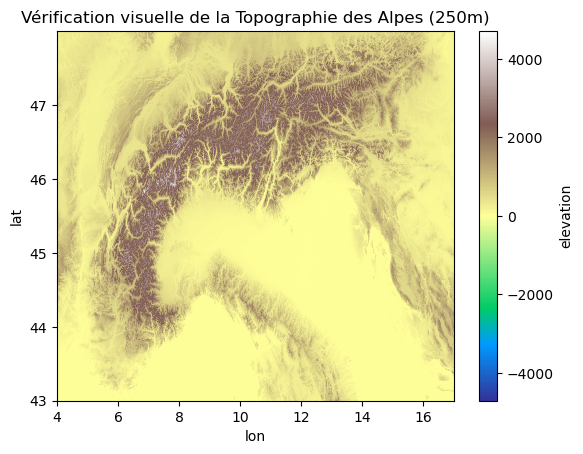

In [3]:
ds_topo_HR = xr.open_dataset("/bettik/PROJECTS/pr-regional-climate/mougina/gmted_topo_alpes_250m.nc")
topo_mondiale_HR = ds_topo_HR['elevation']
lon1, lon2, lat1, lat2 = 4, 17, 43, 48
vrai_topo_alpes_HR = topo_mondiale_HR.sel(
    lon=slice(min(lon1, lon2), max(lon1, lon2)), 
    lat=slice(max(lat1, lat2), min(lat1, lat2))
)
if vrai_topo_alpes_HR.sizes['lat'] == 0:
    vrai_topo_alpes_HR = topo_mondiale_HR.sel(
        lon=slice(min(lon1, lon2), max(lon1, lon2)), 
        lat=slice(min(lat1, lat2), max(lat1, lat2))
    )
print("Dimensions de la topo Alpes :", vrai_topo_alpes_HR.shape)
print("Rugosité Min :", float(vrai_topo_alpes_HR.min()))
print("Rugosité Max :", float(vrai_topo_alpes_HR.max()))

vrai_topo_alpes_HR.plot(cmap='terrain')
plt.title("Vérification visuelle de la Topographie des Alpes (250m)")
plt.show()

In [4]:
facteur_lon = vrai_topo_alpes_HR.shape[1] // ds_grid.LON.shape[1]
facteur_lat = vrai_topo_alpes_HR.shape[0] // ds_grid.LON.shape[0]


sigma_topo_brut = vrai_topo_alpes_HR.coarsen(lon=facteur_lon, lat=facteur_lat, boundary='trim').std()
sigma_topo_aligned = sigma_topo_brut.interp(lon=ds_grid.LON[0, :], lat=ds_grid.LAT[:, 0], method='nearest')
topo_numpy = sigma_topo_aligned.reindex_like(ds_grid, method='nearest').values


In [5]:
#ouverture v2 GF 
file_v2 = '/home/mougina/mes_analyses_neige/Alpine_snow.nc'
ds_v2 = xr.open_dataset(file_v2)

scfg_raw = ds_v2['scfg_interp'].where((ds_v2['scfg_interp'] >= 0) & (ds_v2['scfg_interp'] <= 100))

is_water = ds_v2['mask_water'].fillna(0) == 210
is_ice = ds_v2['mask_ice'].fillna(0) == 215
scfg_final = scfg_raw.where(~is_water & ~is_ice)

In [6]:
z0g = 0.01         
rho_new = 50.0     ## les donnees so nt celle utilise dans l'article de Lalande et al. 2023
m = 1.0
beta = 3*10**-6
n = 3.0

In [7]:
### fonction calcul du rho moyen 
def calc_rho_mean(ds_rho, SD):
    levels_da = xr.DataArray(
        [0, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 2.0, 3.0, 5.0, 10.0, 15.0],
        coords=[ds_rho['outlay']], dims=['outlay']
    )
    
    mask = xr.concat([
        xr.ones_like(ds_rho['RO1'].isel(outlay=[0])),
        (ds_rho['RO1'].diff('outlay') != 0)
    ], dim='outlay')

    # Poids corrigé : le dernier nœud actif s'arrête à SD et non au niveau suivant
    levels_next = levels_da.shift(outlay=-1, fill_value=15.0)
    dz_corrige  = (np.minimum(levels_next, SD) - levels_da.shift(outlay=1, fill_value=0.0)) / 2
    dz_corrige  = dz_corrige.clip(min=0)

    return (ds_rho['RO1'].where(mask)
            .weighted(dz_corrige.where(mask).fillna(0))
            .mean(dim='outlay'))

## Figure 1 

J'ouvre tout pour chaque figure 

In [ ]:
lon_site, lat_site = 6.4, 45.0
lieu = "Lautaret"
year = "2018"
alt_site = ds_topo['elevation'].sel(lat=lat_site, lon=lon_site, method="nearest").values
lieu_titre = f"{lieu} ({int(alt_site)}m)"

output_dir = '/home/mougina/mes_analyses_neige/moyenne_test/evolution_1loc/'
os.makedirs(output_dir, exist_ok=True)

paths = [
    ("V4 Non Gap-filled",    "/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_NGF_global/2018/**/*.nc", "multi"),
    ("V4 Gap-filled",        "/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_GF_alps/SCFG_Alps_2018.nc", "single"),
    ("V2 Non Gap-filled",    "/bettik/PROJECTS/pr-regional-climate/mougina/data_v2_NGF_global/SCFG_v2_NGF_Alps_2018.nc", "single"),
    ("V2 Gap-filled (global)", "/home/mougina/mes_analyses_neige/Alpine_snow.nc", "global")
]

months = ['J','F','M','A','M','J','J','A','S','O','N','D']
data_store = {}  
for label, path, ptype in paths:
    if ptype == "multi":
        ds = xr.open_mfdataset(path, combine='by_coords', decode_cf=True, parallel=True)
    else:
        ds_raw = xr.open_dataset(path, decode_cf=False)
        for v in ds_raw.variables:
            if 'dtype' in ds_raw[v].attrs:
                del ds_raw[v].attrs['dtype']
        ds = xr.decode_cf(ds_raw)

    var_name = 'scfg_interp' if ptype == "global" else 'scfg'
    temp_ds  = ds.sel(time=year) if ptype == "global" else ds

    test_point  = temp_ds[var_name].sel(lon=lon_site, lat=lat_site, method="nearest").squeeze()
    vrai_neige  = ((test_point > 50) & (test_point <= 100)).groupby('time.month').sum(dim='time')
    jour_mesure = ((test_point >= 0) & (test_point <= 100)).groupby('time.month').sum(dim='time')

    data_store[label] = {          
        "neige": vrai_neige.values,
        "total": jour_mesure.values,
    }

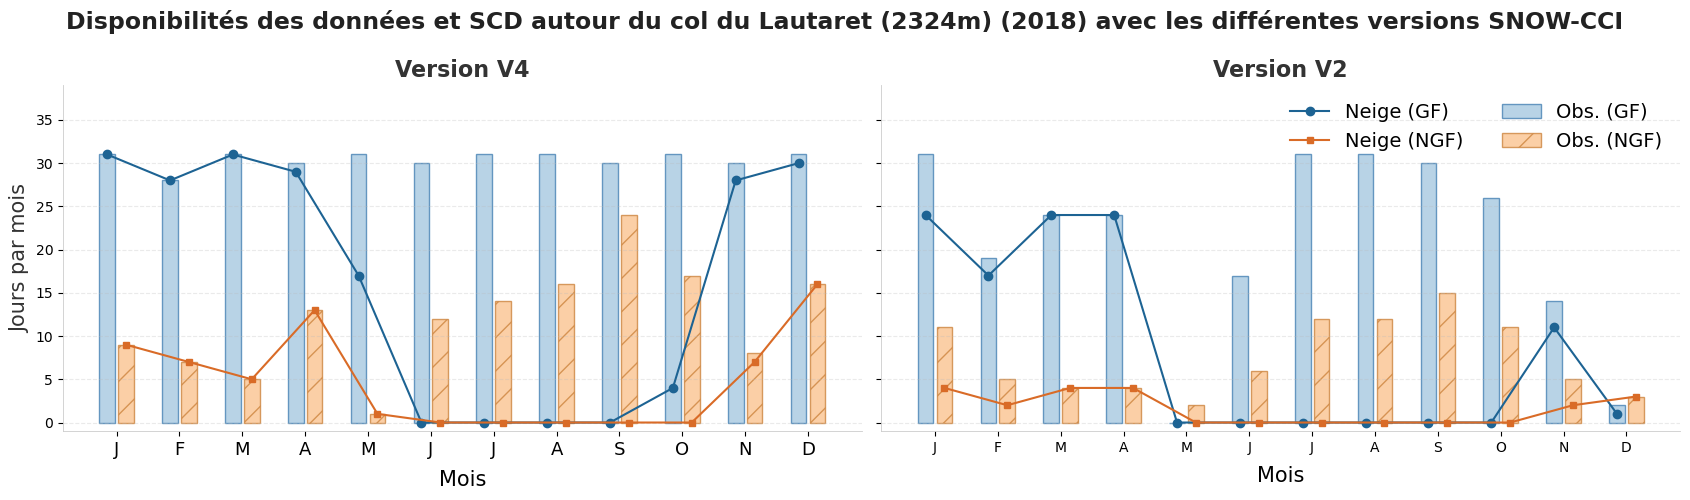

In [16]:


# --- Plot propre ---
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams["font.sans-serif"] = ['Liberation Sans', 'Nimbus Sans', 'Arial', 'DejaVu Sans']
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.6

fig, (ax_v4, ax_v2) = plt.subplots(1, 2, figsize=(17, 5), sharex=True, sharey=True)

x_base = np.arange(1, 13)
offset = 0.15
x_gf  = x_base - offset
x_ngf = x_base + offset

colors = {
    "gf_total":  "#a6c8e0",
    "gf_snow":   "#1d6393",
    "ngf_total": "#fbc490",
    "ngf_snow":  "#d96b27"
}

# V4
ax_v4.bar(x_gf,  data_store["V4 Gap-filled"]["total"],     width=0.25, color=colors["gf_total"],  alpha=0.8, label="Obs. (GF)",  edgecolor='steelblue')
ax_v4.bar(x_ngf, data_store["V4 Non Gap-filled"]["total"],  width=0.25, color=colors["ngf_total"], alpha=0.8, label="Obs. (NGF)", edgecolor='peru', hatch='/')
ax_v4.plot(x_gf,  data_store["V4 Gap-filled"]["neige"],     marker='o', markersize=6, color=colors["gf_snow"],  label="Neige (GF)")
ax_v4.plot(x_ngf, data_store["V4 Non Gap-filled"]["neige"],  marker='s', markersize=5, color=colors["ngf_snow"], label="Neige (NGF)")

# V2
ax_v2.bar(x_gf,  data_store["V2 Gap-filled (global)"]["total"], width=0.25, color=colors["gf_total"],  alpha=0.8, label="Obs. (GF)",  edgecolor='steelblue')
ax_v2.bar(x_ngf, data_store["V2 Non Gap-filled"]["total"],       width=0.25, color=colors["ngf_total"], alpha=0.8, label="Obs. (NGF)", edgecolor='peru', hatch='/')
ax_v2.plot(x_gf,  data_store["V2 Gap-filled (global)"]["neige"], marker='o', markersize=6, color=colors["gf_snow"],  label="Neige (GF)")
ax_v2.plot(x_ngf, data_store["V2 Non Gap-filled"]["neige"],       marker='s', markersize=5, color=colors["ngf_snow"], label="Neige (NGF)")

ax_v4.set_title("Version V4", fontsize=16, color='#333333', fontweight='bold')
ax_v2.set_title("Version V2", fontsize=16, color='#333333', fontweight='bold')
ax_v2.legend(ncol=2, fontsize=14, loc='upper right', frameon=False)

for ax in [ax_v4, ax_v2]:
    ax.set_ylim(-1, 39)
    ax.grid(True, linestyle='--', alpha=0.3, color='#bbbbbb', axis='y')
    ax.set_xlabel("Mois", fontsize=15, labelpad=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

ax_v4.set_ylabel("Jours par mois", fontsize=15, color='#333333')
ax_v4.set_xticks(x_base)
ax_v4.set_xticklabels(months, rotation=0, fontsize=13)

plt.suptitle(
    f"Disponibilités des données et SCD autour du col du {lieu_titre} ({year}) avec les différentes versions SNOW-CCI",
    fontsize=17, color='#222222', weight="bold", y=0.99
)
plt.savefig(os.path.join(output_dir, f'comparaison_neige_{lieu_titre}_2018_v2_vs_v4_histo.png'))
plt.tight_layout()
plt.show()


## Figure 2

In [25]:
years = [2016,2017, 2018]


ouverture des fichiers 

V4 gap-filled

In [26]:
list_v4 = []
for yr in years:
    ds_v_raw = xr.open_dataset(f"/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_GF_alps/SCFG_Alps_{yr}.nc", decode_cf=False)
    for v in ds_v_raw.variables:
        if 'dtype' in ds_v_raw[v].attrs: del ds_v_raw[v].attrs['dtype']
    ds_v = xr.decode_cf(ds_v_raw)
    ds_v['scfg'] = ds_v['scfg'].where(ds_v['scfg'] >= 0).where(ds_v['scfg'] <= 100)
    list_v4.append(ds_v['scfg'])
all_v4 = xr.concat(list_v4, dim='time')
time_pd_v4 = all_v4.time.to_index()
season_labels_v4 = [get_season(t) for t in time_pd_v4]
all_v4 = all_v4.assign_coords(season=('time', season_labels_v4))

winter_v4 = xr.concat([
    all_v4.where(all_v4.season == f"{yr}_DJF", drop=True) for yr in years
], dim='time').mean(dim='time')
winter_v4 = winter_v4.interp(lon=ds_grid.LON, lat=ds_grid.LAT, method="linear", kwargs={'fill_value': np.nan})
winter_v4 = winter_v4.where(alps_ice == True)


V2 gap-filled

In [27]:


list_v2 = []
for yr in years:
    v2_yr = scfg_final.sel(time=slice(f"{yr}-01-01", f"{yr}-12-31"))
    list_v2.append(v2_yr)
all_v2 = xr.concat(list_v2, dim='time')
time_pd_v2 = all_v2.time.to_index()
season_labels_v2 = [get_season(t) for t in time_pd_v2]
all_v2 = all_v2.assign_coords(season=('time', season_labels_v2))

winter_v2 = xr.concat([
    all_v2.where(all_v2.season == f"{yr}_DJF", drop=True) for yr in years
], dim='time').mean(dim='time')
winter_v2 = winter_v2.interp(lon=ds_grid.LON, lat=ds_grid.LAT, method="linear", kwargs={'fill_value': np.nan})
winter_v2 = winter_v2.where(alps_ice == True)



V4 non gap-filled

In [28]:


list_v4_ngf = []
for yr in years:
    ds_ngf = xr.open_mfdataset(f"/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_NGF_global/{yr}/**/*.nc",
                                combine='by_coords', decode_cf=True, parallel=True)
    ds_ngf['scfg'] = ds_ngf['scfg'].where(ds_ngf['scfg'] >= 0).where(ds_ngf['scfg'] <= 100)
    list_v4_ngf.append(ds_ngf['scfg'])
all_v4_ngf = xr.concat(list_v4_ngf, dim='time')
time_pd_v4_ngf = all_v4_ngf.time.to_index()
season_labels_v4_ngf = [get_season(t) for t in time_pd_v4_ngf]
all_v4_ngf = all_v4_ngf.assign_coords(season=('time', season_labels_v4_ngf))

winter_v4_ngf = xr.concat([
    all_v4_ngf.where(all_v4_ngf.season == f"{yr}_DJF", drop=True) for yr in years
], dim='time').mean(dim='time')
winter_v4_ngf = winter_v4_ngf.interp(lon=ds_grid.LON, lat=ds_grid.LAT, method="linear", kwargs={'fill_value': np.nan})
winter_v4_ngf = winter_v4_ngf.where(alps_ice == True)



V2 non gap-filled

In [29]:
data_path = "/bettik/PROJECTS/pr-regional-climate/mougina/data_v2_NGF_global/SCFG_v2_NGF_Alps_20*.nc"
files = sorted(glob.glob(data_path))

if not files:
    raise FileNotFoundError(f"Aucun fichier trouvé dans {data_path}")

ds_ref = xr.open_dataset(files[0])
ref_lat = ds_ref.lat
ref_lon = ds_ref.lon

def preprocess_(ds):  
    variables_to_drop = ['lat_bnds', 'lon_bnds', 'spatial_ref', 'scfg_unc']
    ds = ds.drop_vars([v for v in variables_to_drop if v in ds.variables])
    for var in ds.variables:
        if 'dtype' in ds[var].attrs:
            del ds[var].attrs['dtype']
    ds = ds.reindex(lat=ref_lat, lon=ref_lon, method='nearest')
    return ds

ds = xr.open_mfdataset(files,combine='nested',concat_dim='time',preprocess=preprocess_,coords='minimal',compat='override',join='override',decode_cf=True
)
scfg = ds['scfg'].where((ds['scfg'] >= 0) & (ds['scfg'] <= 100))
time_pd = scfg.time.to_index()
season_labels = [get_season(t) for t in time_pd]
scfg = scfg.assign_coords(season=('time', season_labels))
target_winters = [f"{yr}_DJF" for yr in years]
winter_avg = scfg.where(scfg.season.isin(target_winters), drop=True).mean(dim='time')

if (winter_avg.lon > 180).any():
    winter_avg = winter_avg.assign_coords(lon=(((winter_avg.lon + 180) % 360) - 180))
    winter_avg = winter_avg.sortby('lon')
winter_final = winter_avg.interp(
    lon=ds_grid.LON, 
    lat=ds_grid.LAT, 
    method="linear", 
    kwargs={'fill_value': np.nan}
)

winter_final = winter_final.where(alps_ice == True)



plot

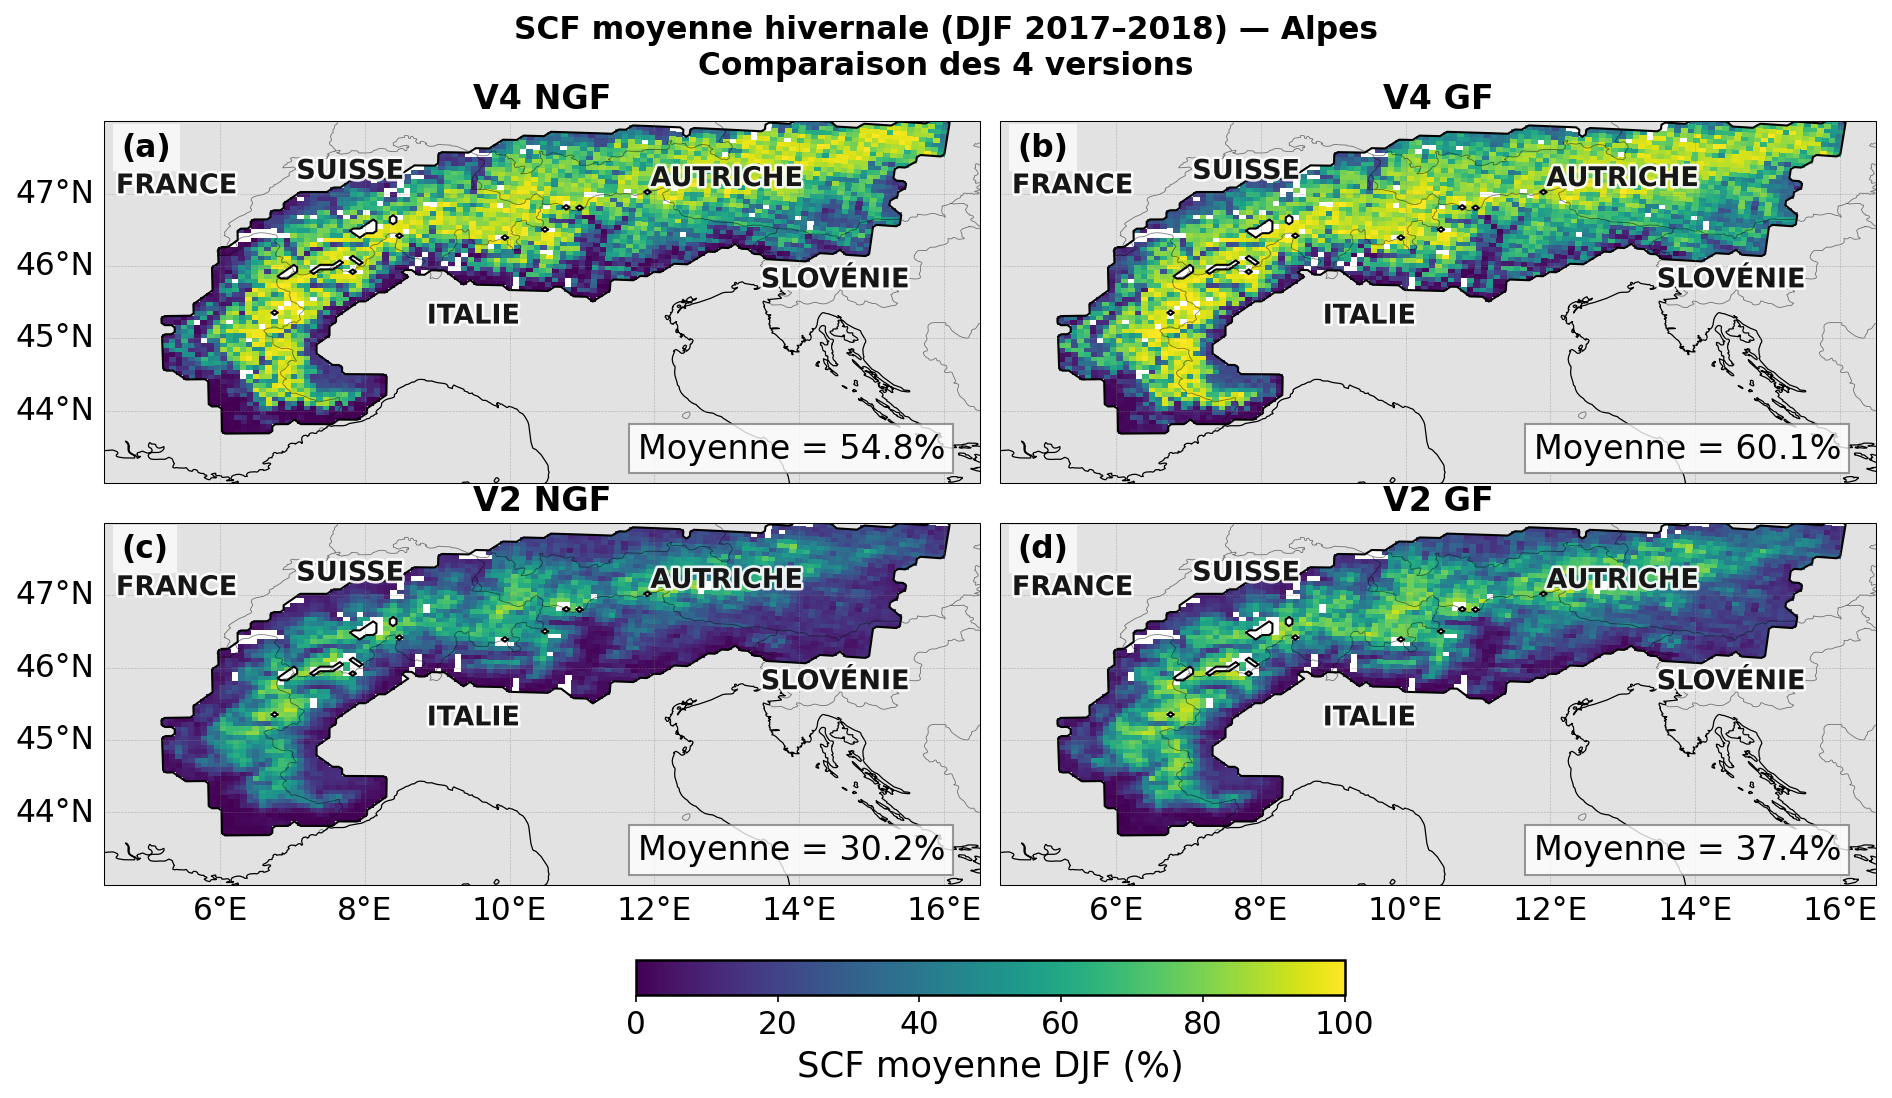

In [59]:

import matplotlib.patheffects as path_effects
lon1, lon2, lat1, lat2 = 4.4, 16.5, 43, 48
plt.rcParams.update({
    'font.family':      'sans-serif',
    'font.sans-serif': ['Liberation Sans', 'Nimbus Sans', 'Arial', 'DejaVu Sans'],
    'font.size':        15,
    'axes.titlesize':   16,
    'figure.dpi':       150,
})

panels = [
    ("V4 NGF", winter_v4_ngf),
    ("V4 GF",  winter_v4),
    ("V2 NGF", winter_final),
    ("V2 GF",  winter_v2),
]

grey_mask = np.where(alps, np.nan, 0.2)

# Coordonnées des pays adaptées aux Alpes
pays_coords = {
    'FRANCE':   (5.4, 47.1),   
    'SUISSE':   (7.8, 47.3),
    'ITALIE':   (9.5, 45.3),
    'AUTRICHE': (13.0, 47.2),
    'SLOVÉNIE': (14.5, 45.8)
}

fig, axs = plt.subplots(2, 2, figsize=(12.5, 7.2),
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        constrained_layout=True)
axs = axs.flatten()


contour_blanc = [path_effects.Stroke(linewidth=2.5, foreground='white'), path_effects.Normal()]

for idx, (label, data) in enumerate(panels):
    ax = axs[idx]
    lettre = f"({chr(97 + idx)})"
    ax.pcolormesh(ds_grid.LON, ds_grid.LAT, grey_mask,
                  cmap='Greys', vmin=0, vmax=1, transform=ccrs.PlateCarree())
    im = ax.pcolormesh(ds_grid.LON, ds_grid.LAT, data.where(alps_ice == True),
                       cmap='viridis', vmin=0, vmax=100, transform=ccrs.PlateCarree())
    
    ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.5)
    ax.contour(lon, lat, alps_ice, levels=[0.5], colors='k', linewidths=1.0, transform=ccrs.PlateCarree())
    
    for nom, (plon, plat) in pays_coords.items():
        if lon1 <= plon <= lon2 and lat1 <= plat <= lat2:
            # 3. TEXTE REMIS EN NOIR BIEN NET (color='k' ou '#111111') ET ALPHA REHAUSSÉ A 0.9 ou 1.0
            t = ax.text(plon, plat, nom, transform=ccrs.PlateCarree(),
                        fontsize=13, fontweight='bold', color='k',
                        ha='center', va='center', alpha=0.9)
            
            # 4. APPLICATION DU CONTOUR BLANC SUR LE TEXTE
            t.set_path_effects(contour_blanc)

    ax.spines['geo'].set_edgecolor('black')
    ax.spines['geo'].set_linewidth(0.5)  
    
    ax.text(0.02, 0.97, lettre, transform=ax.transAxes,
            fontsize=15, fontweight='bold', va='top',
            bbox=dict(fc='white', ec='none', alpha=0.7))
    
    scf_mean = float(np.nanmean(data.where(alps_ice == True)))
    ax.set_title(f"{label}", fontsize=16, fontweight='bold')
    texte_encadre = f"Moyenne = {scf_mean:.1f}%"
    
    ax.text(0.96, 0.05, texte_encadre, transform=ax.transAxes,
                fontsize=16, va='bottom', ha='right', zorder=5,
                bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8))
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    
    if idx % 2 != 0:
        gl.left_labels = False
    if idx < 2:
        gl.bottom_labels = False
        
# Colorbar
cbar = fig.colorbar(im, ax=axs, location='bottom', fraction=0.08, pad=0.04, shrink=0.4)
cbar.set_label('SCF moyenne DJF (%)', fontsize=17)
cbar.outline.set_edgecolor('black')
cbar.outline.set_linewidth(1.2)

plt.suptitle("SCF moyenne hivernale (DJF 2017–2018) — Alpes\nComparaison des 4 versions", size=15, fontweight='bold')
plt.savefig('/home/mougina/mes_analyses_neige/Figure_carte_version_SNOW_CCI.png', dpi=100, bbox_inches='tight')
plt.show()

## Figure 3 

In [9]:
years = [2016, 2017, 2018 ,2019 ,2020 ,2021]
lieu = "Alps"
lat1, lat2, lon1, lon2 =43, 48, 5, 17#45.75, 46, 6.75, 7.15 MB  # zooom possible sur un massif genre belledonne ou quoi 

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


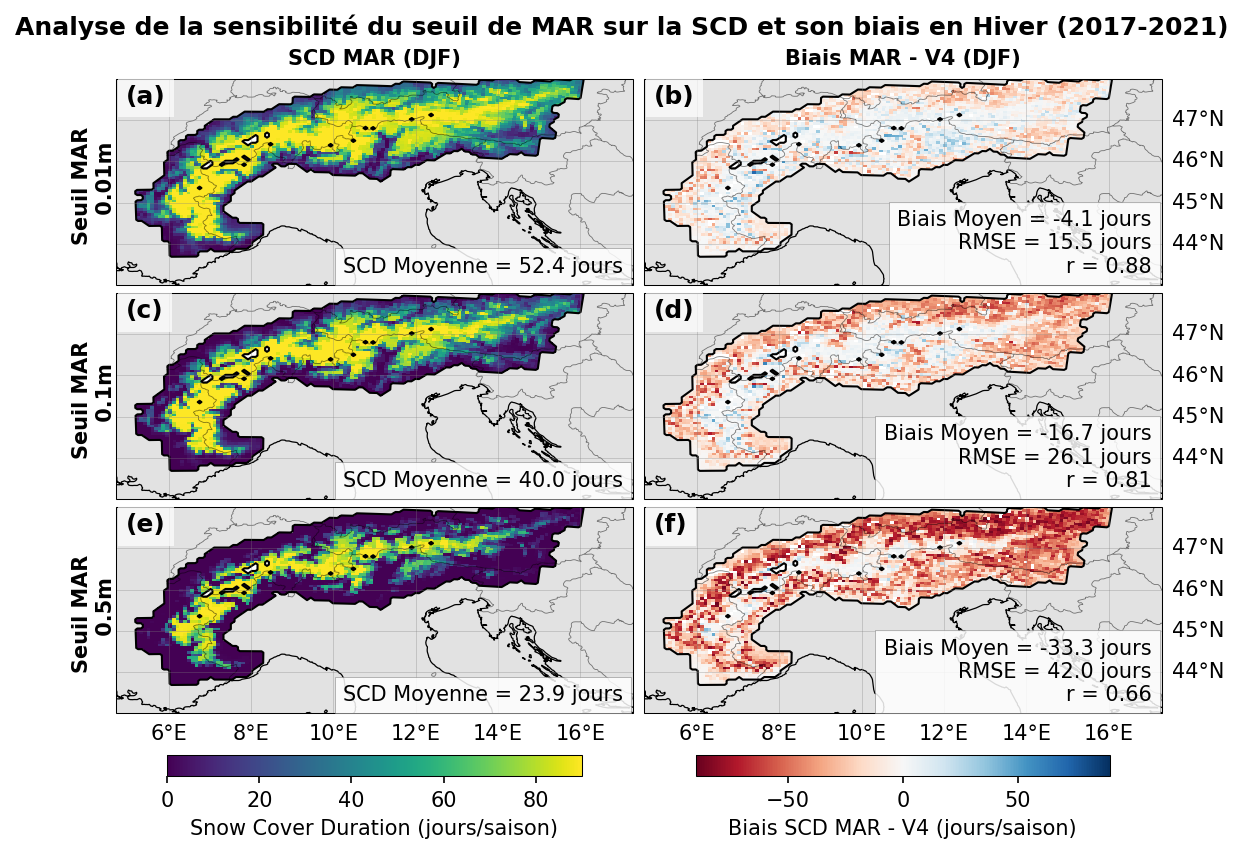

In [19]:

seuil = 50 
seuils_MAR = [0.01, 0.1, 0.5] 
list_mar_raw = []
list_v4 = []

for i, yr in enumerate(years):
    ds_m = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.ZN3.{yr}.nc").isel(sector=0)
    list_mar_raw.append(ds_m['ZN3'])

    ds_v_raw = xr.open_dataset(f"/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_GF_alps/SCFG_Alps_{yr}.nc", decode_cf=False)
    for v in ds_v_raw.variables:
        if 'dtype' in ds_v_raw[v].attrs: 
            del ds_v_raw[v].attrs['dtype']
    ds_v = xr.decode_cf(ds_v_raw)
    
    v4_cont = ds_v['scfg'].where((ds_v['scfg'] >= 0) & (ds_v['scfg'] <= 100), np.nan)
    v4_cont_regrid = v4_cont.interp(lon=ds_grid.LON, lat=ds_grid.LAT, method="linear", kwargs={'fill_value': np.nan})
    
    v4_bin_regrid = xr.where(v4_cont_regrid > seuil, 100.0, 0.0)
    v4_bin_regrid = v4_bin_regrid.where(~np.isnan(v4_cont_regrid))
    
    list_v4.append(v4_bin_regrid)

all_mar_raw = xr.concat(list_mar_raw, dim='time')
all_v4 = xr.concat(list_v4, dim='time')

all_mar_raw = all_mar_raw.sel(time=all_v4.time, method="nearest")
time_pd_v4 = all_v4.time.to_index()
    
season_labels = [get_season(t) for t in time_pd_v4]
all_v4 = all_v4.assign_coords(season=('time', season_labels))
all_mar_raw = all_mar_raw.assign_coords(season=('time', season_labels))

years_to_plot = [yr for yr in years if yr != 2016]
target_winters = [f"{yr}_DJF" for yr in years_to_plot]

winter_v4_clime = all_v4.where(all_v4.season.isin(target_winters), drop=True).mean(dim='time')

rows = []
for seuilMAR in seuils_MAR:
    all_mar_bin = (all_mar_raw > seuilMAR).astype(float) * 100
    winter_mar = all_mar_bin.where(all_mar_bin.season.isin(target_winters), drop=True).mean(dim='time')

    n_days_winter = len(all_v4.where(all_v4.season.isin(target_winters), drop=True).time) / len(years_to_plot)

    scd_mar_jours = winter_mar * n_days_winter / 100
    scd_v4_jours  = winter_v4_clime * n_days_winter / 100
    diff_winter = (winter_mar - winter_v4_clime) * n_days_winter / 100
    
    mask_valid = (alps_ice == True) & (~np.isnan(scd_mar_jours.values)) & (~np.isnan(scd_v4_jours.values))
    x_mar = scd_mar_jours.values[mask_valid]
    x_v4  = scd_v4_jours.values[mask_valid]

    rmse = float(np.sqrt(np.mean((x_mar - x_v4) ** 2)))
    r_value, p_value = scipy_stats.pearsonr(x_mar, x_v4)
    titre_ligne = f"Seuil MAR \n {seuilMAR}m"
    rows.append((titre_ligne, scd_mar_jours, diff_winter, rmse, r_value))  

plt.rcParams.update({
    'font.family':     'sans-serif',
    'font.sans-serif': ['Liberation Sans', 'Nimbus Sans', 'Arial', 'DejaVu Sans'],
    'font.size':       10,
    'axes.titlesize':  11,
    'figure.dpi':      150,
})

fig, axs = plt.subplots(3, 2, figsize=(9, 6.1),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         gridspec_kw={'wspace': 0.02, 'hspace': 0.04})
grey_mask = np.where(alps, np.nan, 0.2)
im_scd = None
im_diff = None
for i, (titre, scd_mar, diff_w,rmse, r_value) in enumerate(rows):
    for j, (ax, data_plot, cmap_name, v_min, v_max, label_titre) in enumerate([
        (axs[i,0], scd_mar.where(alps_ice==True), 'viridis', 0, 90, "SCD MAR"),
        (axs[i,1], diff_w.where(alps_ice==True), 'RdBu', -90, 90, "Biais MAR - V4")
    ]):
        idx = i * 2 + j
        lettre = f"({chr(97 + idx)})" 
        ax.set_adjustable('datalim')
        ax.pcolormesh(ds_grid.LON, ds_grid.LAT, grey_mask,
                      cmap='Greys', vmin=0, vmax=1, transform=ccrs.PlateCarree())

        im = ax.pcolormesh(ds_grid.LON, ds_grid.LAT, data_plot,
                           cmap=cmap_name, vmin=v_min, vmax=v_max,
                           transform=ccrs.PlateCarree())
        if j == 0 and im_scd is None:
            im_scd = im
        if j == 1 and im_diff is None:
            im_diff = im
        ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
        ax.coastlines(linewidth=0.6)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.5)
        ax.contour(lon, lat, alps_ice, levels=[0.5], colors='k', linewidths=1.0)
        ax.spines['geo'].set_edgecolor('black')
        ax.spines['geo'].set_linewidth(0.5)  
        if i == 0:
            column_name = f"{label_titre} (DJF)"
            ax.text(0.5, 1.05, column_name, transform=ax.transAxes,
                    fontsize=10, ha='center', va='bottom', fontweight='bold')

        if j == 0:
            ax.text(-0, 0.5, titre, transform=ax.transAxes,
                    fontsize=10, ha='right', va='center', rotation=90,fontweight='bold',ma='center')
        
        data_mean = float(np.nanmean(data_plot))
        if j == 1:
            stats_text = (f"Biais Moyen = {data_mean:.1f} jours\n"
                          f"RMSE = {rmse:.1f} jours\n"
                          f"r = {r_value:.2f}")
            ax.text(0.98, 0.04, stats_text, transform=ax.transAxes,
                fontsize=10, ha='right', va='bottom', zorder=5,
                bbox=dict(fc='white', ec='gray', lw=0.3, alpha=0.85))
        else:
            stats_text = f"SCD Moyenne = {data_mean:.1f} jours"
            ax.text(0.98, 0.04, stats_text, transform=ax.transAxes,
                fontsize=10, ha='right', va='bottom', zorder=5,
                bbox=dict(fc='white', ec='gray', lw=0.3, alpha=0.85))
        
        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
        gl.top_labels = False
        gl.right_labels = False
        gl.left_labels = False
        gl.bottom_labels = False
        if j == 1:
            gl.right_labels = True
        if i == 2:
            gl.bottom_labels = True
        ax.text(0.02, 0.97, lettre, transform=ax.transAxes,
                    fontsize=12, fontweight='bold', va='top',
                    bbox=dict(fc='white', ec='none', alpha=0.7))
cbar_scd = fig.colorbar(im_scd, ax=axs[:, 0], orientation='horizontal',
                         location='bottom', fraction=0.04, pad=0.06, shrink=0.8)
cbar_scd.set_label('Snow Cover Duration (jours/saison)', fontsize=10)
cbar_scd.outline.set_edgecolor('black')
cbar_scd.outline.set_linewidth(0.5)
cbar_diff = fig.colorbar(im_diff, ax=axs[:, 1], orientation='horizontal',
                          location='bottom', fraction=0.04, pad=0.06, shrink=0.8)
cbar_diff.set_label('Biais SCD MAR - V4 (jours/saison)', fontsize=10)
cbar_diff.outline.set_edgecolor('black')
cbar_diff.outline.set_linewidth(0.5)
plt.suptitle(f"Analyse de la sensibilité du seuil de MAR sur la SCD et son biais en Hiver (2017-2021)", fontsize=12, fontweight='bold', y=0.95)
plt.savefig('/home/mougina/mes_analyses_neige/carte_seuils_MAR_hiver.png', dpi=100, bbox_inches='tight')
plt.show()

## Figure 4  

Les 2 premieres cases peuvent etre executer mais plot aussi des choses inutile, leur seul but est d'ouvir les donnees

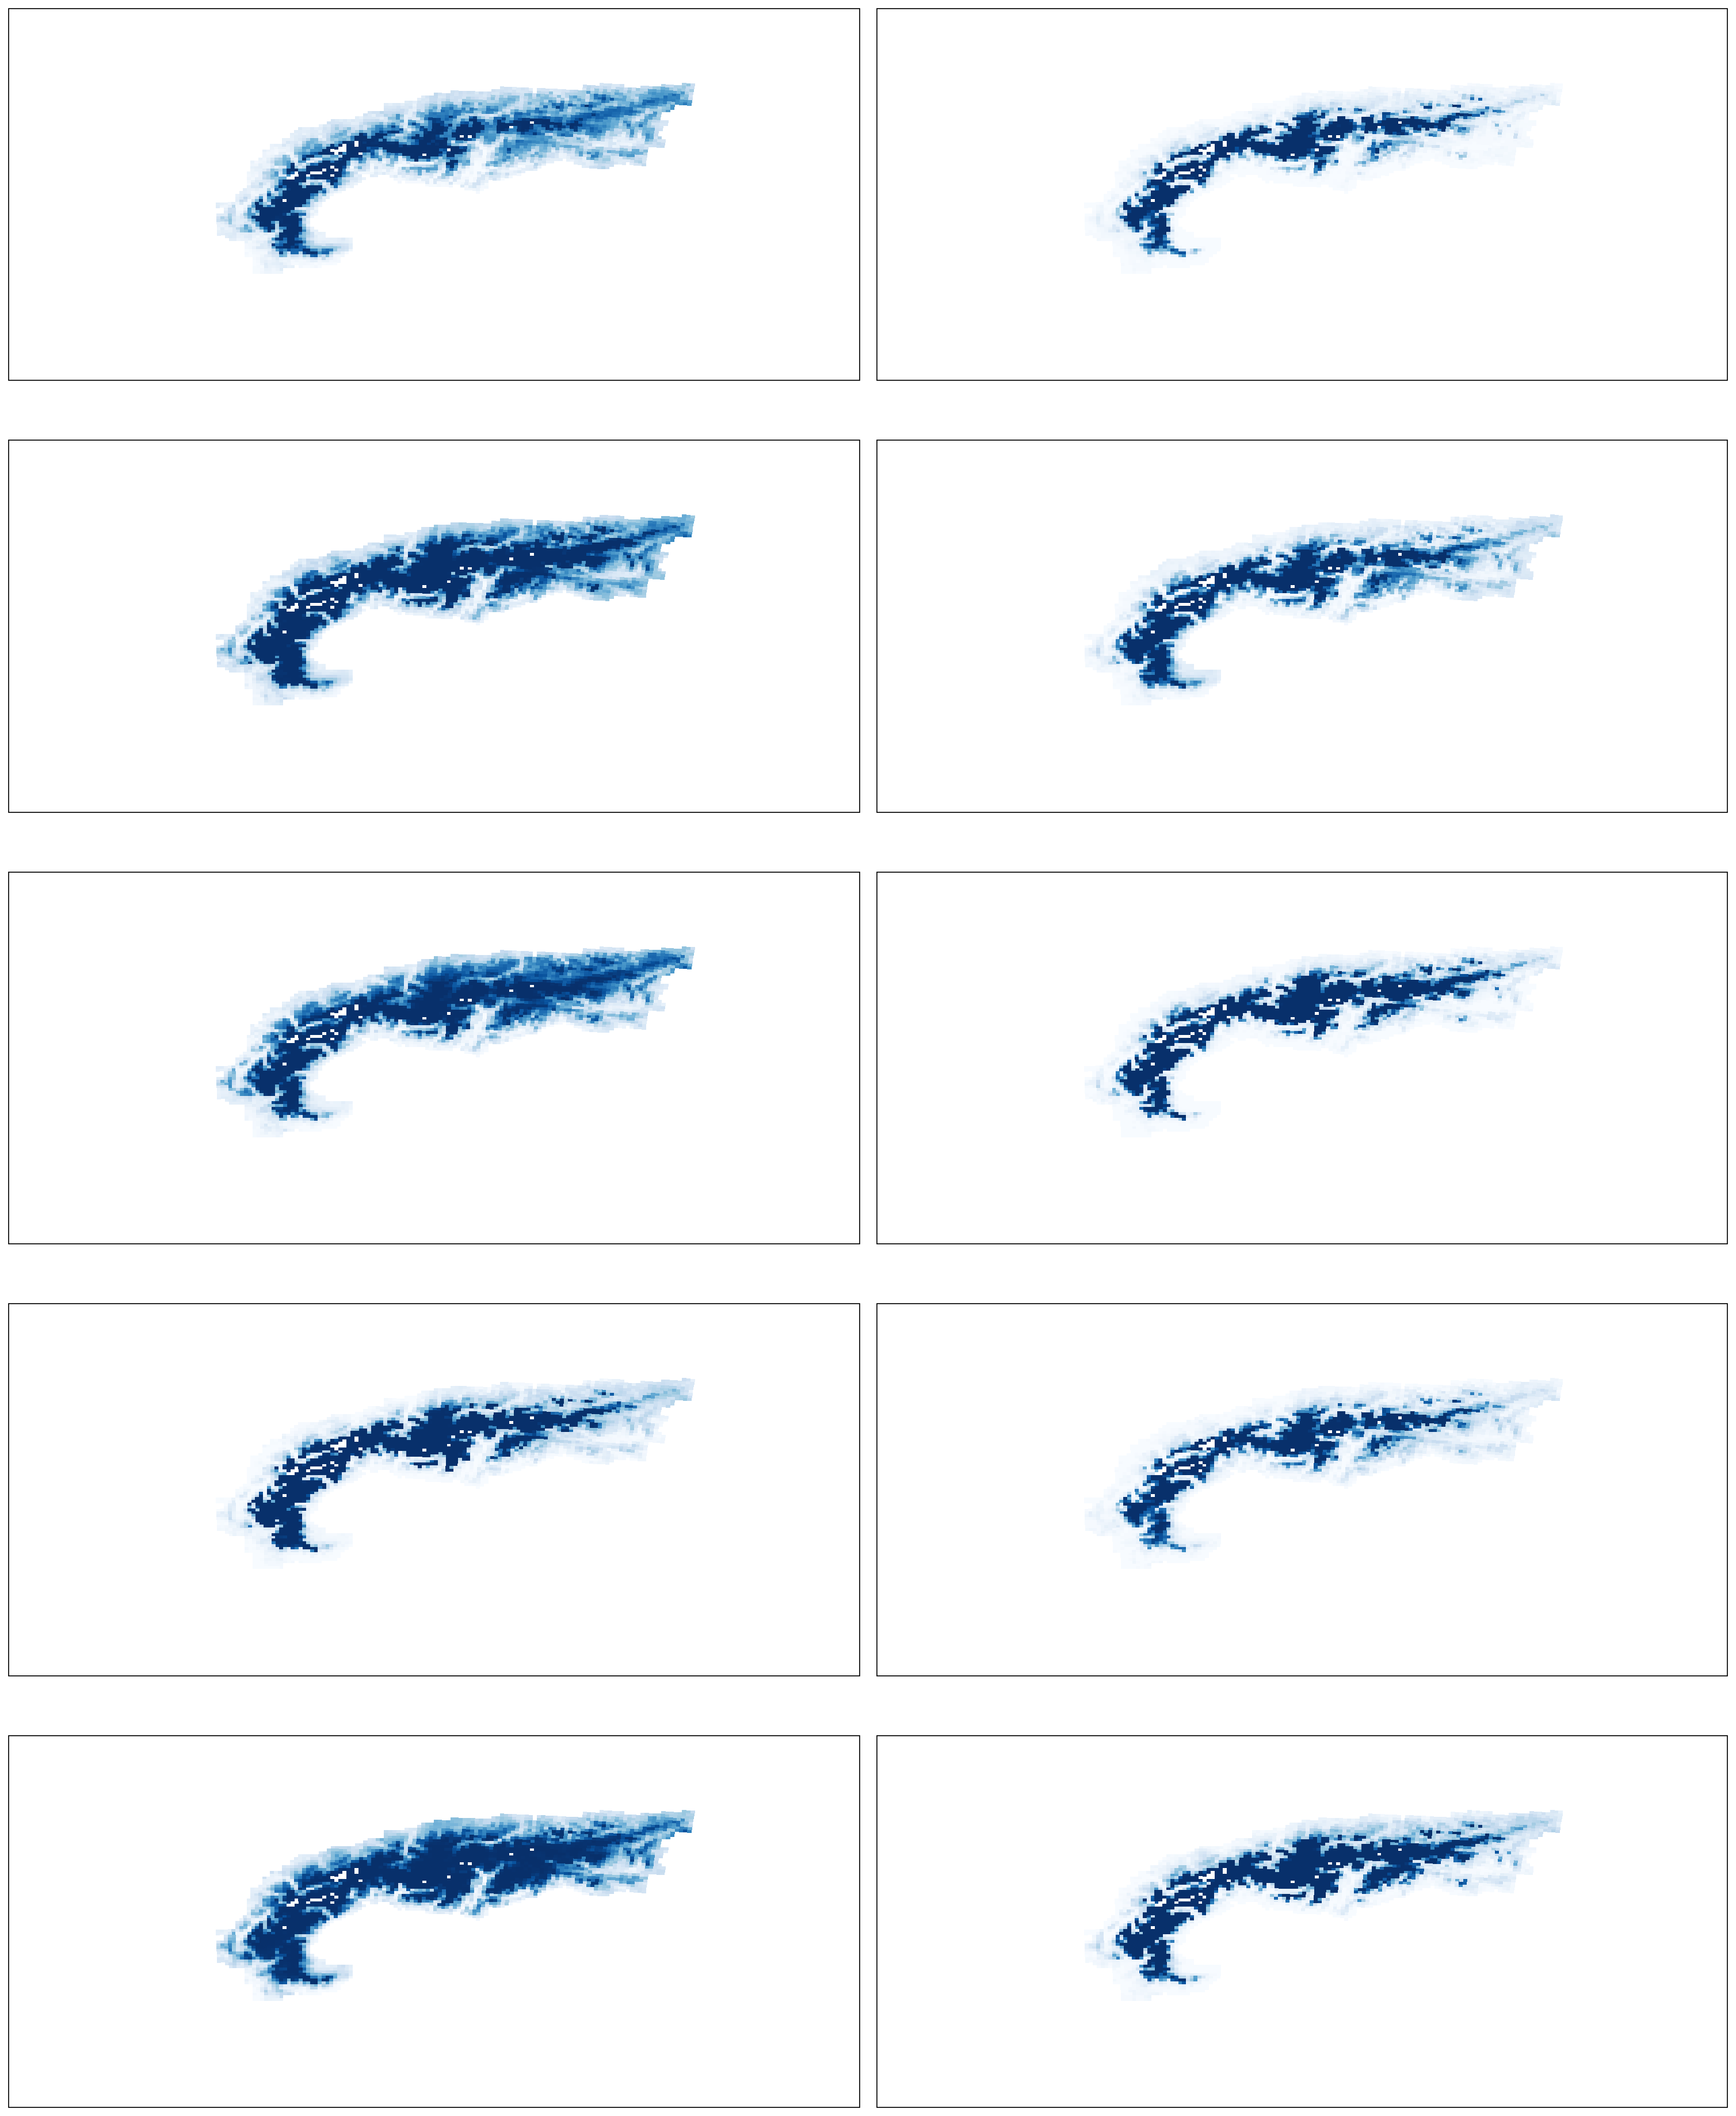

In [33]:
list_mar_NY = []
list_rho = []
for i, yr in enumerate(years):
    ds_m = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.ZN3.{yr}.nc").isel(sector=0)
    ds_rho = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.RO1.{yr}.nc")
    SD = ds_m['ZN3']
    rho_snow = calc_rho_mean(ds_rho, SD)
    denominateur_NY = 2.5 * z0g * ((rho_snow / rho_new) ** m)
    denominateur_safe_NY = denominateur_NY.where(denominateur_NY > 0, other=1e-10)
    scf_mar_NY = xr.where(SD == 0, 0, np.tanh(SD / denominateur_safe_NY) * 100)
    #scf_mar = (scf_mar > seuil).astype(float) * 100 
    list_mar_NY.append(scf_mar_NY)
    
all_mar_NY = xr.concat(list_mar_NY, dim='time')
all_mar_NY = all_mar_NY.sel(time=slice("2016-09-01", "2021-08-31"))
time_pd_mar = all_mar_NY.time.to_index()
    
season_labels = [get_season(t) for t in time_pd_mar]
all_mar_NY= all_mar_NY.assign_coords(season=('time', season_labels))
years_to_plot = [yr for yr in years if yr != 2016]
n_rows = len(years_to_plot)

fig, axs = plt.subplots(n_rows, 2, figsize=(20, 5 * n_rows), 
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         constrained_layout=True)

for i, yr in enumerate(years_to_plot):
    ax = axs[i] 
    target_spring = f"{yr}_MAM"
    target_winter = f"{yr}_DJF"

    spring_mar = all_mar_NY.where(all_mar_NY.season == target_spring, drop=True).mean(dim='time')
    
    
    winter_mar = all_mar_NY.where(all_mar_NY.season == target_winter, drop=True).mean(dim='time')

    spring_mar = spring_mar.where(alps_ice == True)
    winter_mar = winter_mar.where(alps_ice == True)
    im1 = ax[1].pcolormesh(ds_grid.LON, ds_grid.LAT, spring_mar,
                       cmap='Blues', vmin=0, vmax=90, transform=ccrs.PlateCarree())

    im2 = ax[0].pcolormesh(ds_grid.LON, ds_grid.LAT, winter_mar, cmap = 'Blues', vmin=0, vmax=100, transform=ccrs.PlateCarree())

    
    levels = [20, 40, 60, 80]
    colors = ['lightgray', 'silver', 'gray', 'black']


In [34]:
sigma_topo_brut = vrai_topo_alpes_HR.coarsen(lon=facteur_lon, lat=facteur_lat, boundary='trim').std()
sigma_topo_aligned = sigma_topo_brut.interp(lon=ds_grid.LON[0, :], lat=ds_grid.LAT[:, 0], method='nearest')
topo_numpy = sigma_topo_aligned.reindex_like(ds_grid, method='nearest').values

print("Taille finale de la matrice topo_numpy :", topo_numpy.shape)
list_mar_LA = []
list_rho = []

for i, yr in enumerate(years):
    ds_m = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.ZN3.{yr}.nc").isel(sector=0)
    ds_rho = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.RO1.{yr}.nc")
    SD = ds_m['ZN3']
    rho_snow = calc_rho_mean(ds_rho, SD)
    topo_numpy = sigma_topo_aligned.fillna(0).values
    print("NaN ratio:", np.isnan(topo_numpy).sum() / topo_numpy.size)  # doit être 0
    print("Zones avec topo > 0:", (topo_numpy > 0).sum() / topo_numpy.size)

    denominateur_LA = (2.5 * z0g * ((rho_snow / rho_new) ** m)) + (beta * topo_numpy * ((rho_snow / rho_new) ** n))
    denominateur_safe_LA = denominateur_LA.where(denominateur_LA > 0, other=1e-10)
    scf_mar_LA = xr.where(SD == 0, 0, np.tanh(SD / denominateur_safe_LA) * 100)
    
    list_mar_LA.append(scf_mar_LA)
all_mar_LA = xr.concat(list_mar_LA, dim='time')
all_mar_LA = all_mar_LA.sel(time=slice("2016-09-01", "2021-08-31"))
time_pd_mar = all_mar_LA.time.to_index()
    
season_labels = [get_season(t) for t in time_pd_mar]
all_mar_LA= all_mar_LA.assign_coords(season=('time', season_labels))

Taille finale de la matrice topo_numpy : (126, 201)
NaN ratio: 0.0
Zones avec topo > 0: 0.4115533443891653
NaN ratio: 0.0
Zones avec topo > 0: 0.4115533443891653
NaN ratio: 0.0
Zones avec topo > 0: 0.4115533443891653
NaN ratio: 0.0
Zones avec topo > 0: 0.4115533443891653
NaN ratio: 0.0
Zones avec topo > 0: 0.4115533443891653
NaN ratio: 0.0
Zones avec topo > 0: 0.4115533443891653


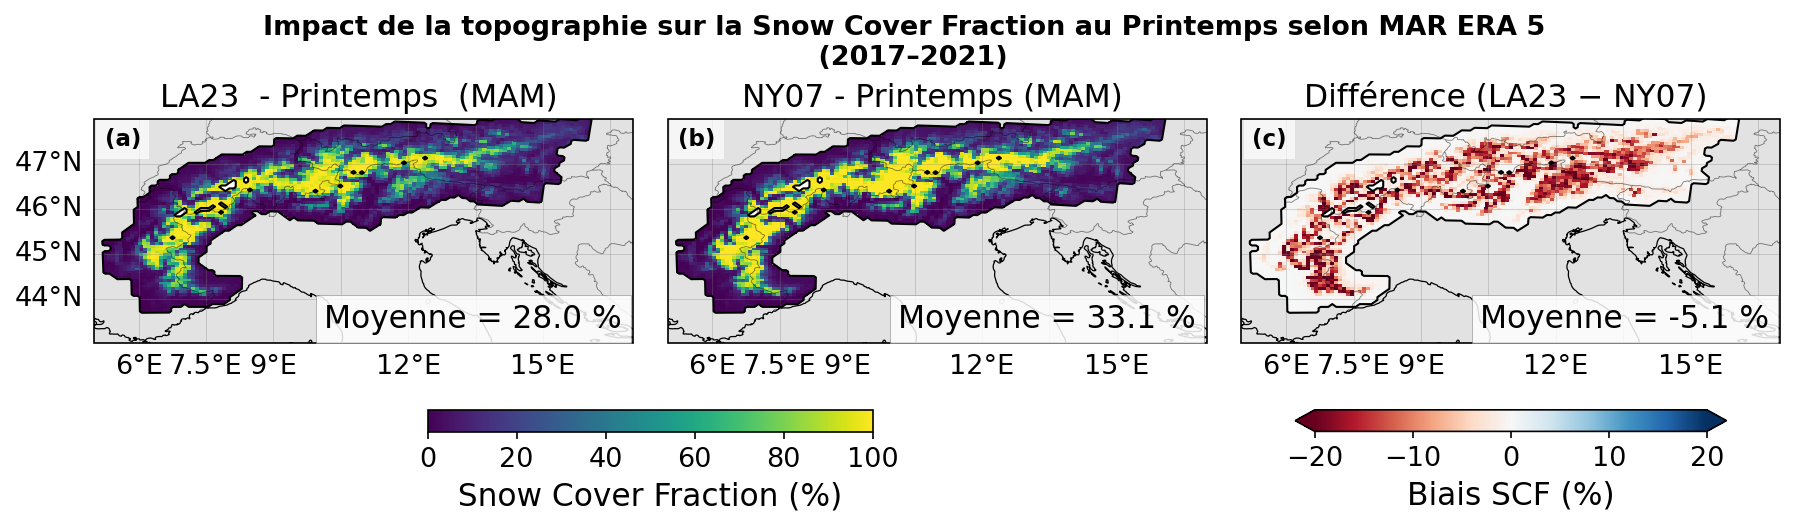

In [46]:

mam_LA = all_mar_LA.where(
    all_mar_LA.time.dt.year.isin(years) & all_mar_LA.season.str.endswith('_MAM'), 
    drop=True
).mean('time').where(alps_ice)

mam_NY = all_mar_NY.where(
    all_mar_NY.time.dt.year.isin(years) & all_mar_NY.season.str.endswith('_MAM'), 
    drop=True
).mean('time').where(alps_ice)

mam_diff = mam_LA - mam_NY
plt.rcParams.update({
    'font.family':     'sans-serif',
    'font.sans-serif': ['Liberation Sans', 'Nimbus Sans', 'Arial', 'DejaVu Sans'],
    'font.size':       13,
    'axes.titlesize':  14,
    'figure.dpi':      150,
})


fig, axs = plt.subplots(1, 3, figsize=(12, 6),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         constrained_layout=True)

panel_labels = ['(a)', '(b)', '(c)']
datasets = [mam_LA, mam_NY, mam_diff]
titles = ['LA23  - Printemps  (MAM)', 'NY07 - Printemps (MAM)', 'Différence (LA23 − NY07)']
cmaps = ['viridis', 'viridis', 'RdBu']
grey_mask = np.where(alps, np.nan, 0.2)

for i, ax in enumerate(axs):
    vmin_val = 0 if i < 2 else -20
    vmax_val = 100 if i < 2 else 20

    ax.pcolormesh(ds_grid.LON, ds_grid.LAT, grey_mask,
                  cmap='Greys', vmin=0, vmax=1, transform=ccrs.PlateCarree(), zorder=1)
    im = ax.pcolormesh(ds_grid.LON, ds_grid.LAT, datasets[i],
                       cmap=cmaps[i], vmin=vmin_val, vmax=vmax_val, transform=ccrs.PlateCarree(), zorder=2)

    ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.6, zorder=3)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.5, zorder=3)
    ax.contour(lon, lat, alps_ice, levels=[0.5], colors='k', linewidths=1.0, transform=ccrs.PlateCarree(), zorder=4)
    mean_val = datasets[i].mean().item()
    signe = "+" if (i == 2 and mean_val > 0) else ""
    ax.set_title(f"{titles[i]} ", fontsize=15)
    ax.text(0.02, 0.96, panel_labels[i], transform=ax.transAxes,
            fontsize=11, fontweight='bold', va='top', zorder=5,
            bbox=dict(fc='white', ec='none', alpha=0.7))
    stats_text = f"Moyenne = {mean_val:.1f} %"
    ax.text(0.98, 0.04, stats_text, transform=ax.transAxes,
                fontsize=15, ha='right', va='bottom', zorder=5,
                bbox=dict(fc='white', ec='gray', lw=0.3, alpha=0.85))
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False 
    gl.left_labels = False
    gl.bottom_labels = True
    gl.left_labels = True if i == 0 else False
    


    if i == 0:
        cbar_abs = fig.colorbar(im, ax=axs[0:2], location='bottom', fraction=0.04, pad=0.04, shrink=0.4)
        cbar_abs.set_label(' Snow Cover Fraction (%) ', fontsize=15)
    elif i == 2:
        cbar_diff = fig.colorbar(im, ax=ax, location='bottom', fraction=0.04,extend='both', pad=0.04, shrink=0.8)
        cbar_diff.set_label('Biais SCF (%)', fontsize=15)

fig.suptitle('Impact de la topographie sur la Snow Cover Fraction au Printemps selon MAR ERA 5 \n (2017–2021)', 
             fontsize=13, fontweight='bold', y=0.56)

plt.savefig('/home/mougina/mes_analyses_neige/carte_analyse_topo_LA_NY_MAM_2017_2021.png', dpi=100)
plt.show()

## Figure 5 

### pour la figure 6 il s'agit du meme code en y ajoutant le seuil et en modifiant les noms et les colorbars (limite) (on repasse en jours/saison plutot qu'en %

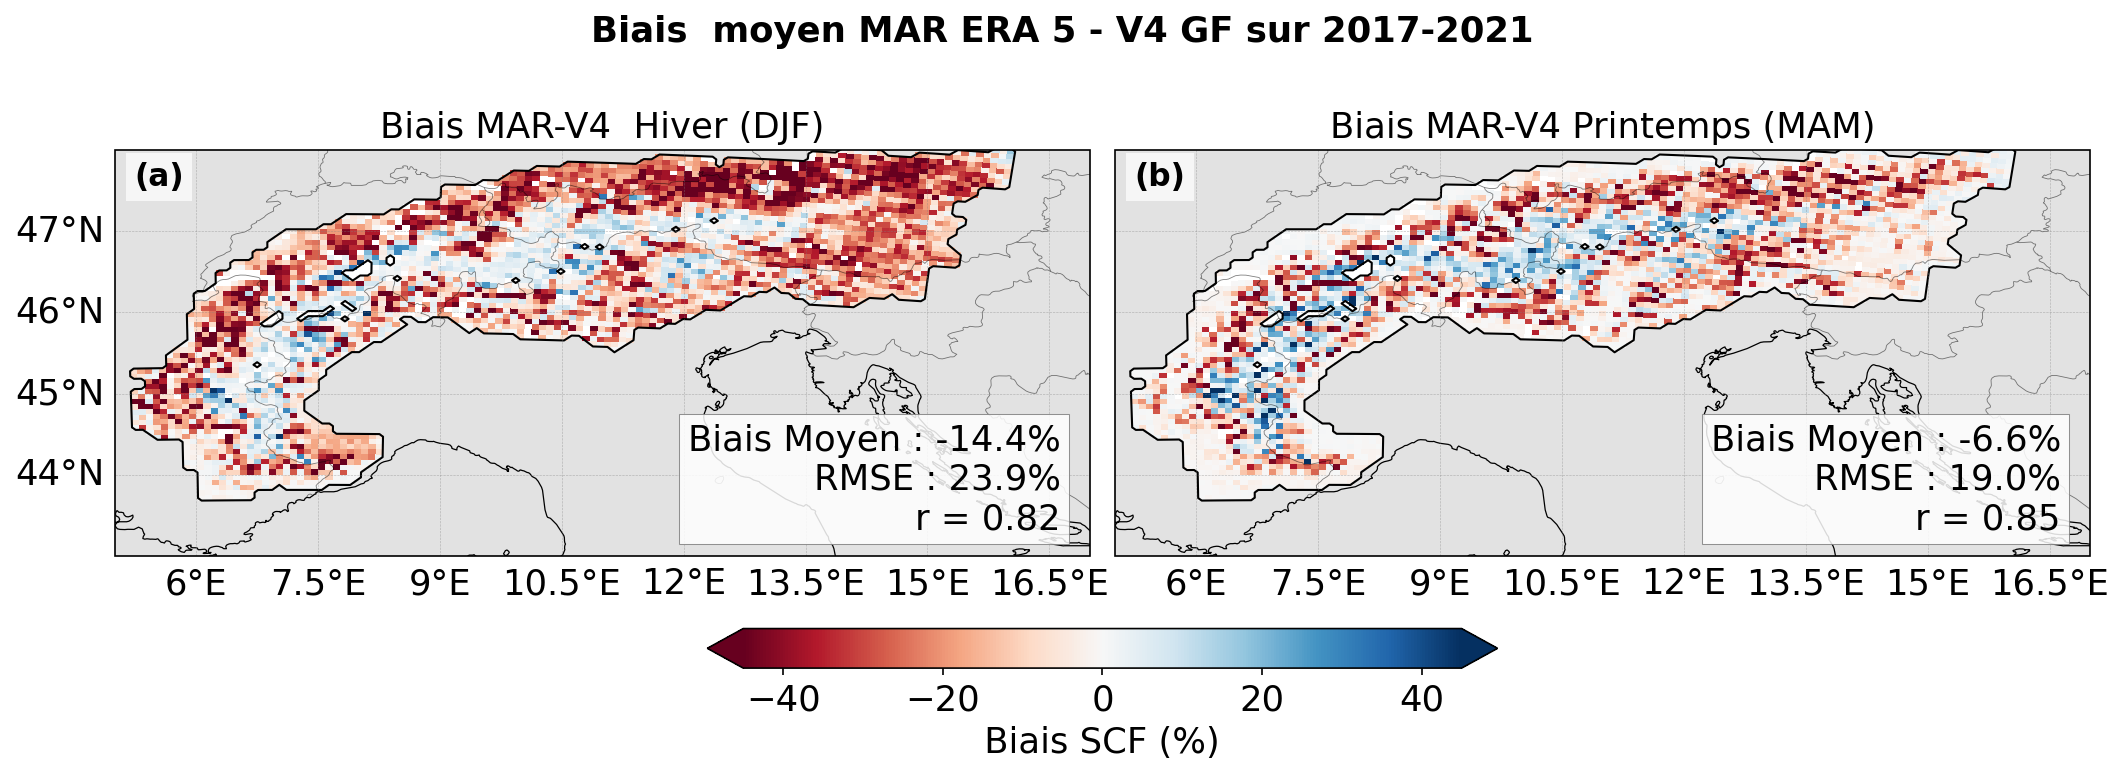

In [10]:
list_mar = []
list_v4 = []
list_rho = []
seuil = 50
for i, yr in enumerate(years):
    ds_m = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.ZN3.{yr}.nc").isel(sector=0)
    ds_rho = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.RO1.{yr}.nc")
    
    
    list_rho.append(ds_rho['RO1'].astype(float))
    
    SD = ds_m['ZN3']
    rho_snow = calc_rho_mean(ds_rho, SD)
    topo_numpy = sigma_topo_aligned.values

    denominateur = (2.5 * z0g * ((rho_snow / rho_new) ** m)) + (beta * topo_numpy * ((rho_snow / rho_new) ** n))
    denominateur_safe = denominateur.where(denominateur > 0, other=1e-10)
    scf_mar = xr.where(SD == 0, 0, np.tanh(SD / denominateur_safe) * 100)
    list_mar.append(scf_mar)
 
    ds_v_raw = xr.open_dataset(f"/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_GF_alps/SCFG_Alps_{yr}.nc", decode_cf=False)
    for v in ds_v_raw.variables:
        if 'dtype' in ds_v_raw[v].attrs: 
            del ds_v_raw[v].attrs['dtype']
    ds_v = xr.decode_cf(ds_v_raw)
    v4_cont = ds_v['scfg'].where((ds_v['scfg'] >= 0) & (ds_v['scfg'] <= 100), np.nan)
    v4_cont_regrid = v4_cont.interp(lon=ds_grid.LON, lat=ds_grid.LAT, method="linear", kwargs={'fill_value': np.nan})
    list_v4.append(v4_cont_regrid)

all_mar = xr.concat(list_mar, dim='time')
all_v4 = xr.concat(list_v4, dim='time')
all_mar = all_mar.sel(time=all_v4.time, method="nearest")

time_pd_v4 = all_v4.time.to_index()
time_pd_mar = all_mar.time.to_index()

season_labels_full = [get_season(t) for t in time_pd_v4]

season_only_labels = [label.split('_')[1] for label in season_labels_full]

all_v4 = all_v4.assign_coords(season=('time', season_only_labels))
all_mar = all_mar.assign_coords(season=('time', season_only_labels))

winter_mar_avg = all_mar.where(all_mar.season == 'DJF', drop=True).mean(dim='time')
winter_v4_avg = all_v4.where(all_v4.season == 'DJF', drop=True).mean(dim='time')

spring_mar_avg = all_mar.where(all_mar.season == 'MAM', drop=True).mean(dim='time')
spring_v4_avg = all_v4.where(all_v4.season == 'MAM', drop=True).mean(dim='time')

diff_winter = (winter_mar_avg - winter_v4_avg).where(alps_ice == True)
diff_spring = (spring_mar_avg - spring_v4_avg).where(alps_ice == True)

mask_valid_winter = (alps_ice == True) & (~np.isnan(winter_mar_avg.values)) & (~np.isnan(winter_v4_avg.values))
x_mar_winter = winter_mar_avg.values[mask_valid_winter]
x_v4_winter  = winter_v4_avg.values[mask_valid_winter]
rmse_winter = float(np.sqrt(np.mean((x_mar_winter - x_v4_winter) ** 2)))
r_winter, p_winter = scipy_stats.pearsonr(x_mar_winter, x_v4_winter)

# --- AJOUT : calcul RMSE et r pour le printemps ---
mask_valid_spring = (alps_ice == True) & (~np.isnan(spring_mar_avg.values)) & (~np.isnan(spring_v4_avg.values))
x_mar_spring = spring_mar_avg.values[mask_valid_spring]
x_v4_spring  = spring_v4_avg.values[mask_valid_spring]
rmse_spring = float(np.sqrt(np.mean((x_mar_spring - x_v4_spring) ** 2)))
r_spring, p_spring = scipy_stats.pearsonr(x_mar_spring, x_v4_spring)
grey_mask = np.where(alps, np.nan, 0.2)


plt.rcParams.update({
    'font.family':    'DejaVu Sans',
    
    'font.size':       17,
    'axes.titlesize':  17,
    'figure.dpi':      150,
})

fig, axs = plt.subplots(1, 2, figsize=(14, 5.5), 
                        subplot_kw={'projection': ccrs.PlateCarree()})

fig.set_layout_engine('constrained', h_pad=0, w_pad=0.02, hspace=0, wspace=0)
seasons_to_plot = [
    (axs[0], diff_winter, ' Hiver (DJF)', '(a)', rmse_winter, r_winter),
    (axs[1], diff_spring, 'Printemps (MAM)', '(b)', rmse_spring, r_spring)
]

for ax_sub, diff, season_name, lettre, rmse, r_value in seasons_to_plot:

    ax_sub.pcolormesh(ds_grid.LON, ds_grid.LAT, grey_mask,
                      cmap='Greys', vmin=0, vmax=1, transform=ccrs.PlateCarree())

    im = ax_sub.pcolormesh(ds_grid.LON, ds_grid.LAT, diff,
                           cmap='RdBu', vmin=-45, vmax=45, transform=ccrs.PlateCarree())

 
    ax_sub.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
    ax_sub.coastlines(linewidth=0.6)
    ax_sub.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.5)
    ax_sub.contour(lon, lat, alps_ice, levels=[0.5], colors='k', linewidths=1.0, transform=ccrs.PlateCarree())
 
    mean_bias = diff.mean().item()
    ax_sub.set_title(f"Biais MAR-V4 {season_name}")
    ax_sub.text(0.02, 0.97, lettre, transform=ax_sub.transAxes,
                fontsize=15, fontweight='bold', va='top',
                bbox=dict(fc='white', ec='none', alpha=0.7))
    stats_text = f"Biais Moyen : {mean_bias:+.1f}%\nRMSE : {rmse:.1f}%\nr = {r_value:.2f}"
    ax_sub.text(0.97, 0.05, stats_text, transform=ax_sub.transAxes,
                fontsize=17,  ha='right', va='bottom', zorder=5,
                bbox=dict(fc='white', ec='gray', lw=0.5, alpha=0.85))

    gl = ax_sub.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    if ax_sub == axs[0]:
        gl.left_labels = True
    else:
        gl.left_labels = False

# Ajustement de la colorbar pour la ligne unique
cbar= fig.colorbar(im, ax=axs, location='bottom', fraction=0.12, pad=0.04, extend='both', shrink=0.4)
cbar.set_label(' Biais SCF (%) ', fontsize=17)

plt.suptitle("Biais  moyen MAR ERA 5 - V4 GF sur 2017-2021", size=17, fontweight='bold',y = 0.90)
plt.savefig('/home/mougina/mes_analyses_neige/carte_biais_moyen_MAR-v4_alps_SCF.png', dpi=100)
plt.show()

## Figure 7 

In [21]:
def calculer_enneigement_site(lon_site, lat_site, lieu, years, ds_grid, scfg_final_v2, annees_dispos_v2):
    print(f"-> Traitement en cours pour le site : {lieu}...")
    dist = ((ds_grid.LON - lon_site)**2 + (ds_grid.LAT - lat_site)**2)
    idx_min = dist.argmin(dim=['x', 'y'])
    target_lon = ds_grid.LON.isel(x=idx_min['x'], y=idx_min['y']).values
    target_lat = ds_grid.LAT.isel(x=idx_min['x'], y=idx_min['y']).values
    alt_site = ds_topo['elevation'].sel(lat=lat_site, lon=lon_site, method="nearest").values

    all_mar_months = []
    all_v4_months_inter = []
    all_v2_months_inter = []
    time_labels = []
    for yr in years:
        # 1. MAR
        ds_m = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.ZN3.{yr}.nc").isel(sector=0)
        ds_rho = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.RO1.{yr}.nc")
        
        SD = ds_m['ZN3']
        rho_snow = calc_rho_mean(ds_rho, SD)
        topo_numpy = sigma_topo_aligned.fillna(0).values
        denominateur_LA = (2.5 * z0g * ((rho_snow / rho_new) ** m)) + (beta * topo_numpy * ((rho_snow / rho_new) ** n))

        scf_mar_LA = np.tanh(SD / denominateur_LA) * 100
        jours_de_neige_mar = (scf_mar_LA > 0).astype(int)
        pt_m = jours_de_neige_mar.where(dist == dist.min(), drop=True).squeeze()
        mar_monthly = pt_m.groupby('time.month').sum()
        all_mar_months.append(mar_monthly.values)

        # 2. V4
        file_v4 = f"/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_GF_alps/SCFG_Alps_{yr}.nc"
        with xr.open_dataset(file_v4, decode_cf=False) as ds_v4_raw:
            for v in ds_v4_raw.variables:
                if 'dtype' in ds_v4_raw[v].attrs: del ds_v4_raw[v].attrs['dtype']
            ds_v4 = xr.decode_cf(ds_v4_raw)

            ds_v4_crop = ds_v4['scfg'].sel(
                lon=slice(target_lon - 0.2, target_lon + 0.2),
                lat=slice(target_lat - 0.2, target_lat + 0.2)
            )
            pt_v4_inter = ds_v4_crop.interp(lon=target_lon, lat=target_lat, method="nearest").load()
            pt_v4_clean = pt_v4_inter.where(pt_v4_inter >= 0).where(pt_v4_inter <= 100)

            v4_monthly_interpol = (pt_v4_clean > 50).groupby('time.month').sum()
            all_v4_months_inter.append(v4_monthly_interpol.values)
        if yr in annees_dispos_v2:
            v2_yr = scfg_final_v2.sel(time=slice(f"{yr}-01-01", f"{yr}-12-31"))
            v2_crop = v2_yr.sel(
                lon=slice(target_lon - 0.2, target_lon + 0.2),
                lat=slice(target_lat - 0.2, target_lat + 0.2)
            )
            pt_v2_inter = v2_crop.interp(lon=target_lon, lat=target_lat, method="nearest").load()
            jours_neige_v2 = (pt_v2_inter > 50).astype(int).groupby('time.month').sum()
            jours_valides_v2 = pt_v2_inter.notnull().astype(int).groupby('time.month').sum()
            jours_totaux_mois = pt_v2_inter.time.dt.days_in_month.groupby('time.month').first()
            v2_mensuel_corrige = (jours_neige_v2 / jours_valides_v2.where(jours_valides_v2 > 0)) * jours_totaux_mois
            all_v2_months_inter.append(v2_mensuel_corrige.fillna(0).values)
        else:
            all_v2_months_inter.append(np.zeros(12))
        for month_idx in range(1, 13):
            time_labels.append(f"{month_idx:02d}-{yr}")
    resultat = {
        "lieu": lieu,
        "alt_site": alt_site,
        "y_mar": np.concatenate(all_mar_months),
        "y_v4_interpol": np.concatenate(all_v4_months_inter),
        "y_v2_interpol": np.concatenate(all_v2_months_inter),
        "time_labels": time_labels
    }
    return resultat

In [22]:
years = range(2017, 2019)
ds_grid = xr.open_dataset("/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/MARgrid_EUo.nc")
scfg_final_v2 = scfg_raw.where(~is_water & ~is_ice)
annees_dispos_v2 = np.unique(ds_v2['time'].dt.year.values)

liste_sites_a_calculer = [{"lieu": "Sion",     "lon":  7.355347,    "lat":46.232103},
    {"lieu": "Col de Porte", "lon": 5.7657623, "lat": 45.2963192},
    {"lieu": "Col du Lautaret",      "lon": 6.4,    "lat": 45.04}
]


tous_les_resultats = []

for site in liste_sites_a_calculer:
    res = calculer_enneigement_site(
        lon_site=site["lon"], 
        lat_site=site["lat"], 
        lieu=site["lieu"], 
        years=years, 
        ds_grid=ds_grid, 
        scfg_final_v2=scfg_final_v2, 
        annees_dispos_v2=annees_dispos_v2
    )
    tous_les_resultats.append(res)

-> Traitement en cours pour le site : Sion...
-> Traitement en cours pour le site : Col de Porte...
-> Traitement en cours pour le site : Col du Lautaret...


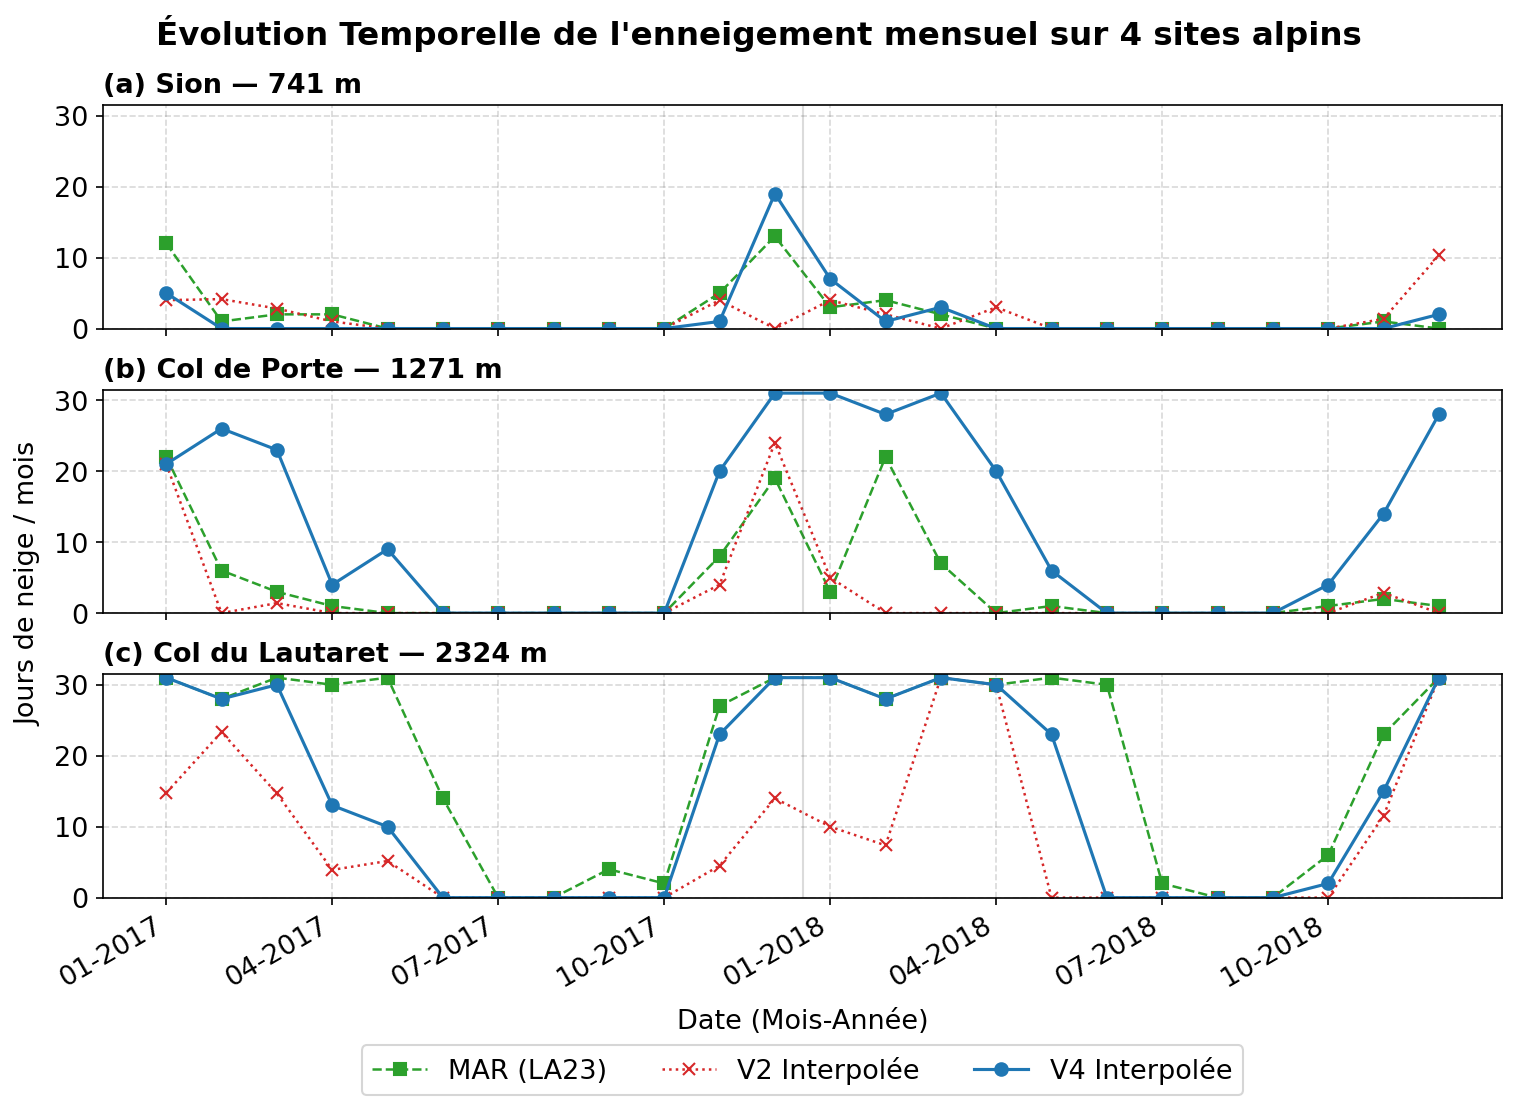

In [26]:
n_sites = len(tous_les_resultats)
x_axis = np.arange(len(tous_les_resultats[0]["time_labels"]))
time_labels = tous_les_resultats[0]["time_labels"]

plt.rcParams.update({
    'font.family':      'DejaVu Sans',
    'font.size':        13,
    'axes.labelsize':   13,
    'figure.dpi':       150,
})

# Création d'une colonne de 4 graphiques (partageant le même axe des X)
fig, axs = plt.subplots(n_sites, 1, figsize=(10, 2.3* n_sites), sharex=True, constrained_layout=True)

for idx, res in enumerate(tous_les_resultats):
    ax = axs[idx]
    ax.plot(x_axis, res["y_mar"], 's--', color='#2ca02c', linewidth=1.2, markersize=6, label="MAR (LA23)")
    ax.plot(x_axis, res["y_v2_interpol"], 'x:', color='#d62728', linewidth=1.2, markersize=6, label="V2 Interpolée")
    ax.plot(x_axis, res["y_v4_interpol"], 'o-', color='#1f77b4', linewidth=1.5, markersize=6, label="V4 Interpolée")

    ax.set_ylim(0, 31.5)
    ax.grid(visible=True, which='major', linestyle='--', alpha=0.3, color='gray')
    for i in range(1, len(years)):
        ax.axvline(i * 12 - 0.5, color='#4d4d4d', linestyle='-', alpha=0.2, linewidth=1)
        
    ax.set_title(f"({chr(97 + idx)}) {res['lieu']} — {int(res['alt_site'])} m", fontweight='bold', loc='left', pad=6, fontsize = 13)
axs[-1].set_xticks(x_axis[::3])
axs[-1].set_xticklabels(time_labels[::3], rotation=30, ha='right')
axs[-1].set_xlabel("Date (Mois-Année)", labelpad=8)
fig.supylabel("Jours de neige / mois", fontsize=13, fontweight='normal')
axs[-1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.6), ncol=3, frameon=True, facecolor='white')

plt.suptitle("Évolution Temporelle de l'enneigement mensuel sur 4 sites alpins", fontweight='bold', y=1.05)
plt.savefig('/home/mougina/mes_analyses_neige/multi_sites_rapport.png', dpi=200, bbox_inches='tight')
plt.show()

## Figure 8 

## Annexes

In [12]:
years = range(1982,2018)
lieu = "Alps"
lat1, lat2, lon1, lon2 =43, 48, 5, 17#45.75, 46, 6.75, 7.15 MB  # zooom possible sur un massif genre belledonne ou quoi 

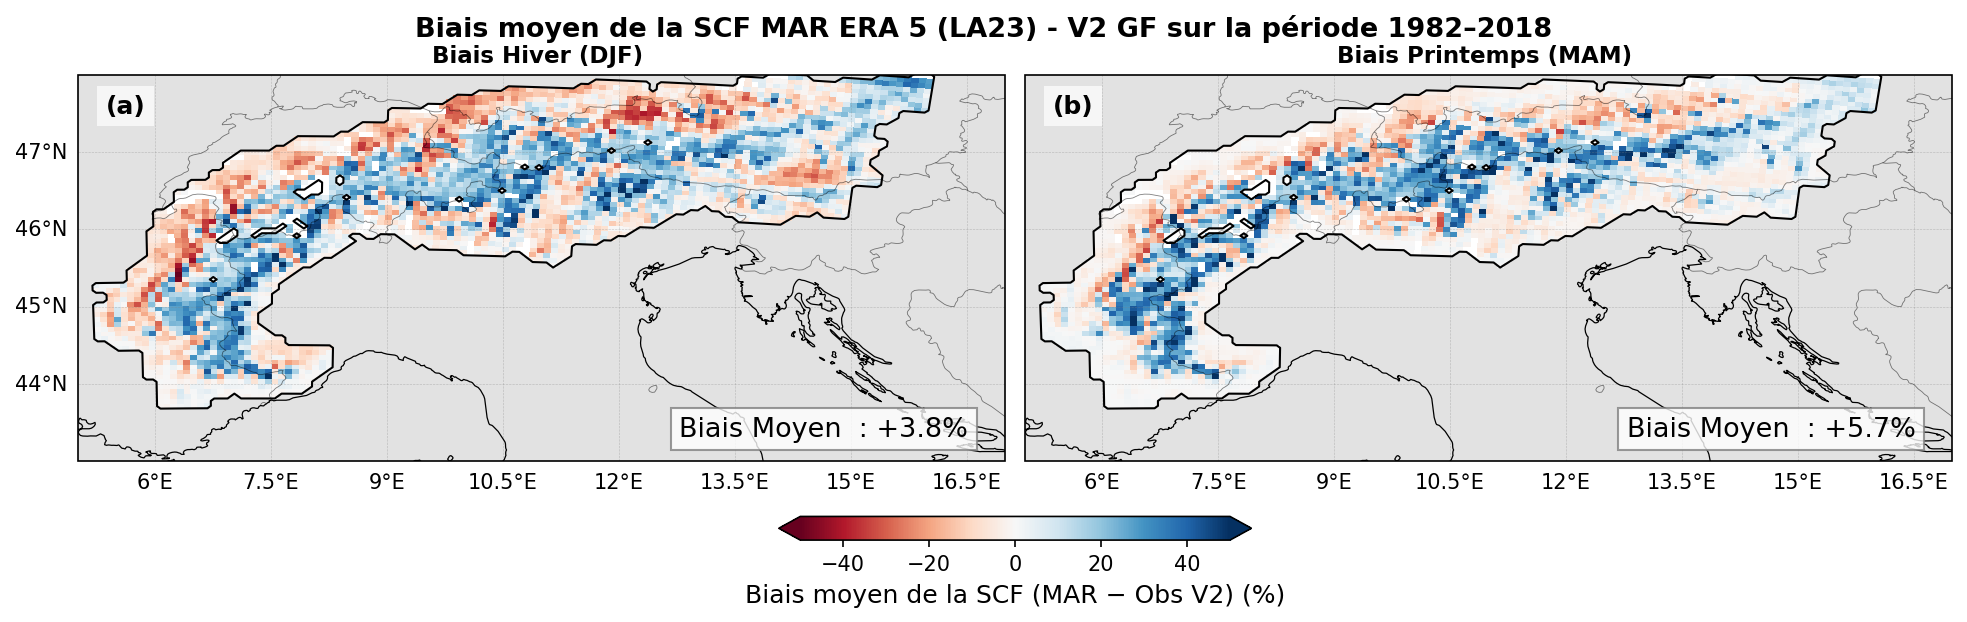

In [13]:

scfg_final = scfg_raw.where(~is_water & ~is_ice)

list_mar = []
list_v2 = []
list_rho = []
for yr in years:
    ds_m = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.ZN3.{yr}.nc").isel(sector=0)
    ds_rho = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.RO1.{yr}.nc")
    
    list_rho.append(ds_rho['RO1'].astype(float))
    SD = ds_m['ZN3']
    rho_snow = calc_rho_mean(ds_rho, SD)
    
    topo_numpy = sigma_topo_aligned.values

    denominateur = (2.5 * z0g * ((rho_snow / rho_new) ** m)) + (beta * topo_numpy * ((rho_snow / rho_new) ** n))
    denominateur_safe = denominateur.where(denominateur > 0, other=1e-10)
    scf_mar = xr.where(SD == 0, 0, np.tanh(SD / denominateur_safe) * 100)
    
    list_mar.append(scf_mar)
 
    v2_yr = scfg_final.sel(time=slice(f"{yr}-01-01", f"{yr}-12-31"))
    list_v2.append(v2_yr)

all_mar = xr.concat(list_mar, dim='time')
all_v2 = xr.concat(list_v2, dim='time')
all_mar = all_mar.sel(time=all_v2.time, method="nearest")
time_pd_v2 = all_v2.time.to_index()
season_labels = [get_season(t) for t in time_pd_v2]

all_mar = all_mar.assign_coords(season=('time', season_labels))
all_v2 = all_v2.assign_coords(season=('time', season_labels))
years_to_plot = [yr for yr in years if yr != 2016]
n_rows = len(years_to_plot)

plt.rcParams.update({
    'font.family':    'sans-serif',
    'font.size':       10,
    'axes.titlesize':  11,
    'figure.dpi':      150,
})

winter_all_mar = all_mar.where(all_mar.season.str.endswith('_DJF'), drop=True)
winter_all_v2  = all_v2.where(all_v2.season.str.endswith('_DJF'), drop=True)

spring_all_mar = all_mar.where(all_mar.season.str.endswith('_MAM'), drop=True)
spring_all_v2  = all_v2.where(all_v2.season.str.endswith('_MAM'), drop=True)

winter_mar_avg = winter_all_mar.mean(dim='time')
spring_mar_avg = spring_all_mar.mean(dim='time')

winter_v2_avg = winter_all_v2.mean(dim='time')
spring_v2_avg = spring_all_v2.mean(dim='time')

winter_v2_regrid = winter_v2_avg.interp(lon=ds_grid.LON, lat=ds_grid.LAT, method="linear", kwargs={'fill_value': np.nan})
spring_v2_regrid = spring_v2_avg.interp(lon=ds_grid.LON, lat=ds_grid.LAT, method="linear", kwargs={'fill_value': np.nan})

diff_winter_avg = (winter_mar_avg - winter_v2_regrid).where(alps_ice == True)
diff_spring_avg = (spring_mar_avg - spring_v2_regrid).where(alps_ice == True)
fig, axs = plt.subplots(1, 2, figsize=(13, 5),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         constrained_layout=True)

grey_mask = np.where(alps, np.nan, 0.2)
seasons_to_plot = [
    (axs[0], diff_winter_avg, 'Hiver (DJF)', '(a)'),
    (axs[1], diff_spring_avg, 'Printemps (MAM)', '(b)')
]

for j, (ax_sub, diff, season_name, lettre) in enumerate(seasons_to_plot):
    ax_sub.pcolormesh(ds_grid.LON, ds_grid.LAT, grey_mask,
                      cmap='Greys', vmin=0, vmax=1, transform=ccrs.PlateCarree(), zorder=1)
    im = ax_sub.pcolormesh(ds_grid.LON, ds_grid.LAT, diff,
                           cmap='RdBu', vmin=-50, vmax=50, transform=ccrs.PlateCarree(), zorder=2)
    ax_sub.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
    ax_sub.coastlines(linewidth=0.6, zorder=3)
    ax_sub.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.5, zorder=3)
    ax_sub.contour(lon, lat, alps_ice, levels=[0.5], colors='k', linewidths=1.0, transform=ccrs.PlateCarree(), zorder=4)
    ax_sub.set_title(f"Biais {season_name} ", fontsize=11, fontweight='bold')
    ax_sub.text(0.03, 0.95, lettre, transform=ax_sub.transAxes,
                fontsize=12, fontweight='bold', va='top', zorder=5,
                bbox=dict(fc='white', ec='none', alpha=0.7))
    biais_moyen_spatial = diff.mean().item()
    signe = "+" if biais_moyen_spatial > 0 else ""
    texte_encadre = f"Biais Moyen  : {signe}{biais_moyen_spatial:.1f}%"
    
    ax_sub.text(0.96, 0.05, texte_encadre, transform=ax_sub.transAxes,
                fontsize=13, va='bottom', ha='right', zorder=5,
                bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8))
    gl = ax_sub.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.4, linestyle='--')
    gl.top_labels = gl.right_labels = False
    gl.left_labels = True if j == 0 else False 
    gl.bottom_labels = True

cbar = fig.colorbar(im, ax=axs, location='bottom', fraction=0.04, pad=0.04, shrink=0.5, extend='both')
cbar.set_label('Biais moyen de la SCF (MAR − Obs V2) (%)', fontsize=12)

# CORRECTION : Ajustement du y à 1.02 pour éviter que le titre écrase les cartes
fig.suptitle("Biais moyen de la SCF MAR ERA 5 (LA23) - V2 GF sur la période 1982–2018", 
             size=13, fontweight='bold', y=0.8)

plt.savefig('/home/mougina/mes_analyses_neige/carte_biais_climatologique_MAR-v2_alps_LA23.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
years = [2016,2017, 2018]
lieu = "alpes"
lat1, lat2, lon1, lon2 = 43, 48, 5, 17  # zooom possible sur un massif genre belledonne ou quoi

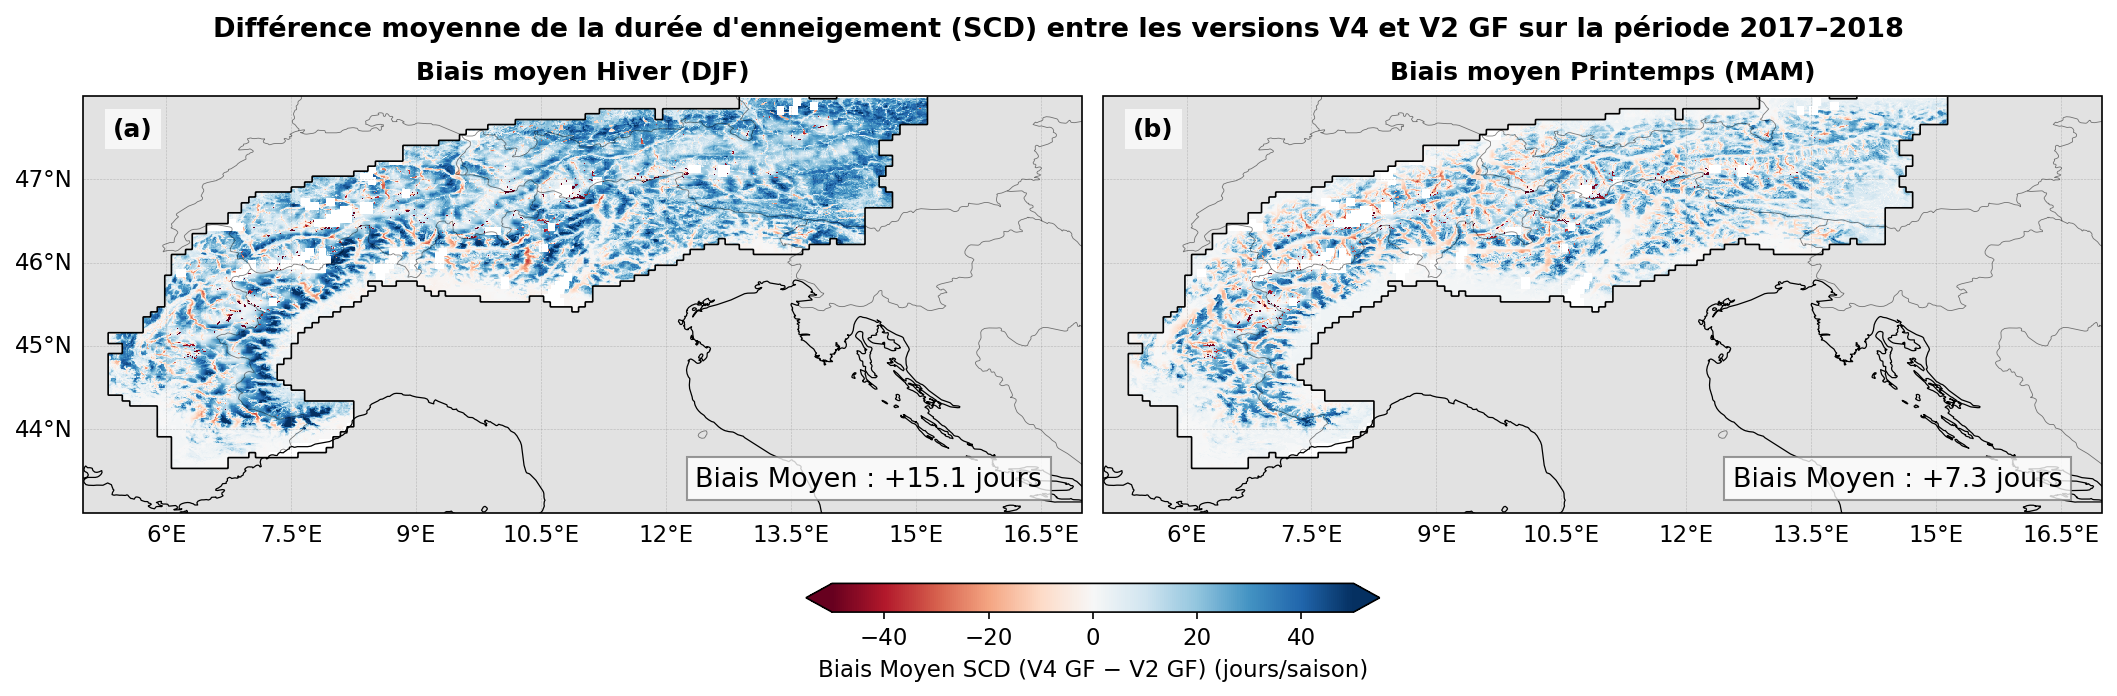

In [10]:
scfg_final = scfg_raw.where(~is_water & ~is_ice)
mask_valide = scfg_final.notnull()
scfg_final = (scfg_final > 50).astype(float) * 100
scfg_final = scfg_final.where(mask_valide)

list_v4 = []
list_v2 = []

for yr in years:
    ds_v_raw = xr.open_dataset(f"/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_GF_alps/SCFG_Alps_{yr}.nc", decode_cf=False)
    for v in ds_v_raw.variables:
        if 'dtype' in ds_v_raw[v].attrs: 
            del ds_v_raw[v].attrs['dtype']
    ds_v = xr.decode_cf(ds_v_raw)

    scfg_v4 = (ds_v['scfg'].where((ds_v['scfg'] >= 0) & (ds_v['scfg'] <= 100), np.nan) > 50).astype(float) * 100
    list_v4.append(scfg_v4)

    v2_yr = scfg_final.sel(time=slice(f"{yr}-01-01", f"{yr}-12-31"))
    list_v2.append(v2_yr)

all_v4 = xr.concat(list_v4, dim='time')
all_v2 = xr.concat(list_v2, dim='time')

time_pd_v4 = all_v4.time.to_index()
time_pd_v2 = all_v2.time.to_index()

season_labels_v4 = [get_season(t).split('_')[1] for t in time_pd_v4]
season_labels_v2 = [get_season(t).split('_')[1] for t in time_pd_v2]

all_v4 = all_v4.assign_coords(season=('time', season_labels_v4))
all_v2 = all_v2.assign_coords(season=('time', season_labels_v2))

alps_da = xr.DataArray(alps.astype(int), coords=[ds_grid.LAT[:, 0], ds_grid.LON[0, :]], dims=['lat', 'lon'])
alps_v4_grid = alps_da.interp(lon=ds_v.lon, lat=ds_v.lat, method="nearest") == 1
winter_v4_avg = all_v4.where(all_v4.season == 'DJF', drop=True).mean(dim='time')
spring_v4_avg = all_v4.where(all_v4.season == 'MAM', drop=True).mean(dim='time')

winter_v2_avg = all_v2.where(all_v2.season == 'DJF', drop=True).mean(dim='time')
spring_v2_avg = all_v2.where(all_v2.season == 'MAM', drop=True).mean(dim='time')

winter_v2_regrid = winter_v2_avg.interp(lon=ds_v.lon, lat=ds_v.lat, method="linear", kwargs={'fill_value': np.nan})
spring_v2_regrid = spring_v2_avg.interp(lon=ds_v.lon, lat=ds_v.lat, method="linear", kwargs={'fill_value': np.nan})

n_years = len(years)
n_days_winter = len(all_v4.where(all_v4.season == 'DJF', drop=True).time) / n_years
n_days_spring = len(all_v4.where(all_v4.season == 'MAM', drop=True).time) / n_years

diff_winter = (winter_v4_avg - winter_v2_regrid) * n_days_winter / 100
diff_spring = (spring_v4_avg - spring_v2_regrid) * n_days_spring / 100

diff_winter = diff_winter.where(alps_v4_grid == True)
diff_spring = diff_spring.where(alps_v4_grid == True)
plt.rcParams.update({
    'font.family':    'sans-serif',
    'font.size':       11,
    'axes.titlesize':  12,
    'figure.dpi':      150,
})

fig, axs = plt.subplots(1, 2, figsize=(14, 6), subplot_kw={'projection': ccrs.PlateCarree()}, constrained_layout=True)
vmax_diff = 50

seasons_to_plot = [
    (axs[0], diff_winter, 'Hiver (DJF)', '(a)'),
    (axs[1], diff_spring, 'Printemps (MAM)', '(b)')
]

grey_mask_v4 = np.where(alps_v4_grid, np.nan, 0.2)

for j, (ax_sub, diff, season_name, lettre) in enumerate(seasons_to_plot):
    ax_sub.pcolormesh(ds_v.lon, ds_v.lat, grey_mask_v4,
                      cmap='Greys', vmin=0, vmax=1, transform=ccrs.PlateCarree(), zorder=1)
    im = ax_sub.pcolormesh(ds_v.lon, ds_v.lat, diff, 
                           cmap='RdBu', vmin=-vmax_diff, vmax=vmax_diff, transform=ccrs.PlateCarree(), zorder=2)
    ax_sub.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
    ax_sub.add_feature(cfeature.BORDERS, linestyle='-', linewidth=0.4, alpha=0.5, zorder=3)
    ax_sub.coastlines(linewidth=0.6, zorder=3)
    ax_sub.contour(ds_v.lon, ds_v.lat, alps_v4_grid, colors='black', linewidths=0.8, transform=ccrs.PlateCarree(), zorder=4)
    ax_sub.set_title(f"Biais moyen {season_name}", fontweight='bold', pad=8)
    ax_sub.text(0.03, 0.95, lettre, transform=ax_sub.transAxes,
                fontsize=12, fontweight='bold', va='top', zorder=5,
                bbox=dict(fc='white', ec='none', alpha=0.7))
    biais_moyen_spatial = diff.mean().item()
    signe = "+" if biais_moyen_spatial > 0 else ""
    texte_encadre = f"Biais Moyen : {signe}{biais_moyen_spatial:.1f} jours"
    
    ax_sub.text(0.96, 0.05, texte_encadre, transform=ax_sub.transAxes,
                fontsize=13, va='bottom', ha='right', zorder=5,
                bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8))
    gl = ax_sub.gridlines(draw_labels=True, color='gray', alpha=0.4, linewidth=0.3, linestyle='--')
    gl.top_labels = gl.right_labels = False
    gl.left_labels = True if j == 0 else False
    gl.bottom_labels = True

cbar = fig.colorbar(im, ax=axs, location='bottom', fraction=0.04, pad=0.05, extend='both', shrink=0.5)
cbar.set_label('Biais Moyen SCD (V4 GF − V2 GF) (jours/saison)', fontsize=11)

fig.suptitle(f"Différence moyenne de la durée d'enneigement (SCD) entre les versions V4 et V2 GF sur la période {years[1]}–{years[-1]}", 
             size=13, fontweight='bold', y=0.75)

plt.savefig('/home/mougina/mes_analyses_neige/carte_biais_v4-v2_alps_moyen.png', dpi=200, bbox_inches='tight')
plt.show()

In [31]:
years = [2016,2017,2018,2019,2020,2021]
lieu = "alpes"
lat1, lat2, lon1, lon2 =  43, 48, 5, 17 

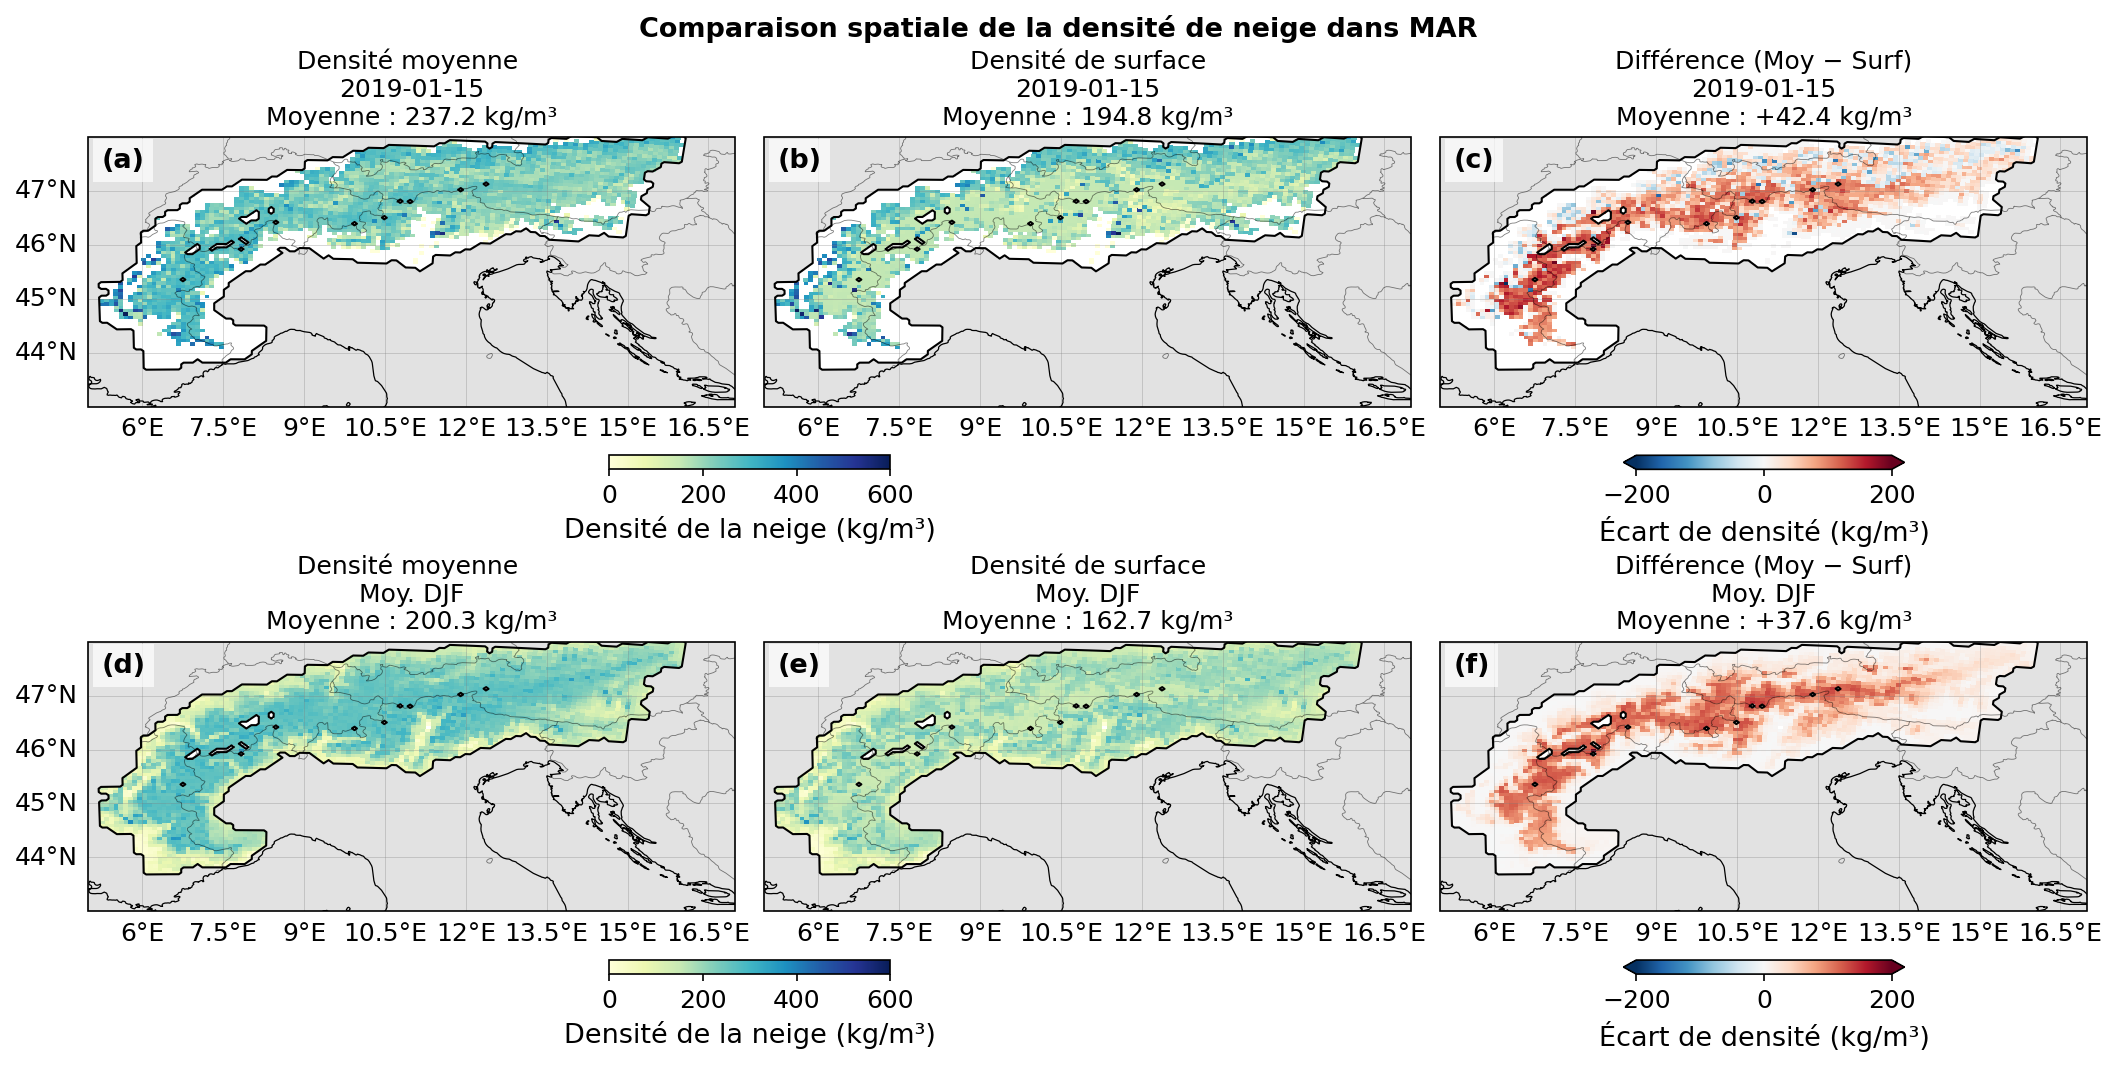

In [32]:
list_mar_moyenne = []
list_mar_surface = []
for i, yr in enumerate(years):
    ds_m   = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.ZN3.{yr}.nc").isel(sector=0)
    ds_rho = xr.open_dataset(f"/bettik/castelli/data/MAR-ERA5/MAR3.14/EUo/daily/ICE.ERA5_HIST.EUo.RO1.{yr}.nc")
    
    SD = ds_m['ZN3']
    
    rho_mean = calc_rho_mean(ds_rho, SD)
    list_mar_moyenne.append(rho_mean)
    
    rho_surf = ((ds_rho['RO1'].isel(outlay=0) + ds_rho['RO1'].isel(outlay=1)) / 2).where(SD > 0)
    list_mar_surface.append(rho_surf)

all_mar_moyenne = xr.concat(list_mar_moyenne, dim='time')
all_mar_surface = xr.concat(list_mar_surface, dim='time')
all_mar_moyenne = all_mar_moyenne.where(alps_ice)
all_mar_surface = all_mar_surface.where(alps_ice)

# --- Date unique ---
date_test = "2019-01-15"
snap_moyenne = all_mar_moyenne.sel(time=date_test, method='nearest').squeeze()
snap_surface = all_mar_surface.sel(time=date_test, method='nearest').squeeze()
snap_diff    = snap_moyenne - snap_surface

# --- Moyenne DJF ---
djf_moyenne = all_mar_moyenne.where(all_mar_moyenne['time.season'] == 'DJF').mean('time')
djf_surface = all_mar_surface.where(all_mar_surface['time.season'] == 'DJF').mean('time')
djf_diff    = djf_moyenne - djf_surface

# --- Plot ---
plt.rcParams.update({
    'font.family':     'sans-serif',
    'font.sans-serif': ['Liberation Sans', 'Nimbus Sans', 'Arial', 'DejaVu Sans'],
    'font.size':       12,
    'axes.titlesize':  13,
    'figure.dpi':      150,
})

fig, axs = plt.subplots(2, 3, figsize=(14, 7),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         constrained_layout=True)

panel_labels = [['(a)', '(b)', '(c)'], ['(d)', '(e)', '(f)']]
row_datasets = [
    [snap_moyenne, snap_surface, snap_diff],
    [djf_moyenne,  djf_surface,  djf_diff],
]
row_titles = [
    [f'Densité moyenne \n{date_test}', f'Densité de surface\n{date_test}', f'Différence (Moy − Surf)\n{date_test}'],
    ['Densité moyenne \nMoy. DJF',     'Densité de surface\nMoy. DJF',     'Différence (Moy − Surf)\nMoy. DJF'],
]
cmaps = ['YlGnBu', 'YlGnBu', 'RdBu_r']
grey_mask = np.where(alps, np.nan, 0.2)

for row in range(2):
    for col, ax in enumerate(axs[row]):
        vmin_val = 0   if col < 2 else -200
        vmax_val = 600 if col < 2 else  200

        ax.pcolormesh(ds_grid.LON, ds_grid.LAT, grey_mask,
                      cmap='Greys', vmin=0, vmax=1, transform=ccrs.PlateCarree(), zorder=1)
        im = ax.pcolormesh(ds_grid.LON, ds_grid.LAT, row_datasets[row][col],
                           cmap=cmaps[col], vmin=vmin_val, vmax=vmax_val,
                           transform=ccrs.PlateCarree(), zorder=2)
        ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
        ax.coastlines(linewidth=0.6, zorder=3)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.5, zorder=3)
        ax.contour(ds_grid.LON, ds_grid.LAT, alps_ice, levels=[0.5],
                   colors='k', linewidths=1.0, transform=ccrs.PlateCarree(), zorder=4)

        mean_val = row_datasets[row][col].mean().item()
        signe = "+" if (col == 2 and mean_val > 0) else ""
        ax.set_title(f"{row_titles[row][col]}\nMoyenne : {signe}{mean_val:.1f} kg/m³", fontsize=12)
        ax.text(0.02, 0.96, panel_labels[row][col], transform=ax.transAxes,
                fontsize=13, fontweight='bold', va='top', zorder=5,
                bbox=dict(fc='white', ec='none', alpha=0.7))

        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
        gl.top_labels    = False
        gl.right_labels  = False
        gl.left_labels   = True if col == 0 else False
        gl.bottom_labels = True

        # Colorbars : une par ligne, partagée entre col 0 et 1, une pour col 2
        if col == 0:
            cbar_abs = fig.colorbar(im, ax=axs[row, 0:2], location='bottom',
                                    fraction=0.04, pad=0.04, shrink=0.5)
            cbar_abs.set_label('Densité de la neige (kg/m³)', fontsize=13)
        elif col == 2:
            cbar_diff = fig.colorbar(im, ax=axs[row, 2], location='bottom',
                                     fraction=0.04, extend='both', pad=0.04, shrink=0.9)
            cbar_diff.set_label('Écart de densité (kg/m³)', fontsize=13)

fig.suptitle('Comparaison spatiale de la densité de neige dans MAR', 
             fontsize=13, fontweight='bold')

plt.savefig('/home/mougina/mes_analyses_neige/comparaison_spatiale_densite.png', dpi=150, bbox_inches='tight')
plt.show()